# Reproducible Ablation Study of NyS-Binary

In [1]:
# =============================================================================
# 0. ENVIRONMENT SETUP & IMPORTS
# =============================================================================
import os, sys, time, copy, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Guarantee TESTS/Github is first in sys.path
BENCHMARK_DIR = r'./'
if BENCHMARK_DIR in sys.path:
    sys.path.remove(BENCHMARK_DIR)
sys.path.insert(0, BENCHMARK_DIR)

# Reload modules cleanly
for mod in ['rigorous_ablation_system', 'advanced_baselines', 'benchmark_new_algebraic']:
    if mod in sys.modules:
        del sys.modules[mod]

import rigorous_ablation_system as ras
import benchmark_new_algebraic as bna
import advanced_baselines as ab

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Rigorous Ablation System loaded successfully!")
print(f"Device: {DEVICE} | PyTorch: {torch.__version__}")
print(f"Canonical Baselines registered: {len(ras.CANONICAL_BASELINES)}")

# =============================================================================
# NON-MASK DATA SPLITTING & ZERO-LEAKAGE UTILITIES
# =============================================================================
MASKS_ROOT = r'./masks'

def get_non_mask_data(ds_name, labels, seed=42, base_mask_frac=0.7, masks_root=MASKS_ROOT):
    """
    Retrieves boolean mask indicating the non-mask data (known pool, e.g. 70%)
    versus mask data (held-out pool, e.g. 30%).
    First checks masks_root for precomputed mask file for the dataset and seed.
    If not found, creates a stratified 70/30 base split using seed.
    """
    n = len(labels)
    dataset_map = {
        "cora": "Cora", "citeseer": "CiteSeer", "pubmed": "PubMed", "wikics": "WikiCS",
        "photo": "AmazonPhotos", "amazon-photo": "AmazonPhotos", "amazon_photos": "AmazonPhotos",
        "chameleon": "chameleon", "squirrel": "squirrel", "actor": "actor",
        "amazon-ratings": "amazon-ratings", "minesweeper": "minesweeper",
        "texas": "texas", "wisconsin": "wisconsin", "cornell": "cornell"
    }
    mask_file = None
    ds_key = str(ds_name).lower().strip()
    if ds_key in dataset_map and os.path.exists(masks_root):
        folder_name = dataset_map[ds_key]
        tag = f"{int(round(base_mask_frac * 100))}_{int(round((1 - base_mask_frac) * 100))}"
        candidate = os.path.join(masks_root, folder_name, tag, f"{folder_name}_{tag}_masked_indices_seed{seed}.npy")
        if os.path.exists(candidate):
            mask_file = candidate

    if mask_file is not None:
        try:
            masked_idx = np.load(mask_file)
            base_non_mask = np.ones(n, dtype=bool)
            base_non_mask[masked_idx] = False
            return base_non_mask
        except Exception:
            pass

    try:
        from sklearn.model_selection import StratifiedShuffleSplit
        sss = StratifiedShuffleSplit(n_splits=1, train_size=base_mask_frac, random_state=seed)
        tr_idx, _ = next(sss.split(np.zeros(n), labels))
        base_non_mask = np.zeros(n, dtype=bool)
        base_non_mask[tr_idx] = True
        return base_non_mask
    except Exception:
        rng = np.random.RandomState(seed)
        perm = rng.permutation(n)
        k = int(round(base_mask_frac * n))
        base_non_mask = np.zeros(n, dtype=bool)
        base_non_mask[perm[:k]] = True
        return base_non_mask

def split_non_mask_data(base_non_mask, labels, seed, train_ratio):
    """
    Takes ONLY the non-mask data and splits it again into the required training ratio.
    Returns:
        train_mask (np.ndarray of bool): Exactly train_ratio of non-mask data.
        test_mask (np.ndarray of bool): The remaining (1 - train_ratio) of non-mask data.
    Guarantees:
        - train_mask is strictly a subset of base_non_mask.
        - test_mask is strictly a subset of base_non_mask.
        - train_mask & test_mask is False everywhere (strictly disjoint).
        - Zero leakage: No test node or masked node is ever in train_mask.
    """
    n = len(labels)
    nm_indices = np.where(base_non_mask)[0]
    n_nm = len(nm_indices)
    
    if train_ratio <= 0.0:
        train_mask = np.zeros(n, dtype=bool)
        test_mask = np.zeros(n, dtype=bool)
        test_mask[nm_indices] = True
        return train_mask, test_mask
    
    rng = np.random.RandomState(seed)
    perm = rng.permutation(nm_indices)
    split_pt = max(1, int(round(train_ratio * n_nm)))
    split_pt = min(split_pt, n_nm - 1) if n_nm > 1 else split_pt
    
    train_indices = perm[:split_pt]
    test_indices = perm[split_pt:]
    
    train_mask = np.zeros(n, dtype=bool)
    train_mask[train_indices] = True
    
    test_mask = np.zeros(n, dtype=bool)
    test_mask[test_indices] = True
    
    # Assert disjointness and zero leakage
    assert not np.any(train_mask & test_mask), "FATAL: train_mask and test_mask overlap!"
    assert np.all(train_mask <= base_non_mask), "FATAL: train_mask contains nodes outside non-mask data!"
    assert np.all(test_mask <= base_non_mask), "FATAL: test_mask contains nodes outside non-mask data!"
    
    return train_mask, test_mask

print("Zero-Leakage Non-Mask Splitting utilities initialized successfully!")


Rigorous Ablation System loaded successfully!
Device: cuda | PyTorch: 2.5.1
Canonical Baselines registered: 9
Zero-Leakage Non-Mask Splitting utilities initialized successfully!


In [ ]:
# =============================================================================
# SECTION 1: SCIENTIFIC SANITY CHECKS & ZERO-LEAKAGE VERIFICATION (NON-MASK DATA)
# =============================================================================
# Run sanity checks on non-mask data.

ds_cora = bna.load_dataset('cora', root=os.path.join(BENCHMARK_DIR, 'data'))
G_cora = ds_cora["G"]
pyg_cora = ds_cora["pyg_data"]
y_cora = ds_cora["labels"]
n_cora = G_cora.number_of_nodes()
e_idx_cora = getattr(pyg_cora, 'edge_index', None)
n_classes_cora = int(np.max(y_cora)) + 1
seed_cora = 42

base_non_mask_cora = get_non_mask_data('cora', y_cora, seed=seed_cora, base_mask_frac=0.7, masks_root=MASKS_ROOT)
n_nm_cora = int(base_non_mask_cora.sum())

print("=" * 80)
print(f"  SCIENTIFIC SANITY CHECKS & ZERO-LEAKAGE VERIFICATION (CORA)")
print(f"  Total Nodes: {n_cora} | Non-Mask Data Pool: {n_nm_cora} ({n_nm_cora/n_cora*100:.1f}%) | Masked: {n_cora - n_nm_cora}")
print("=" * 80)

# -------------------------------------------------------------------------
# Check 1: Multi-Ratio Zero Test Label Leakage Unit Tests
# -------------------------------------------------------------------------
cfg_clean = ras.AblationConfig(device=DEVICE, seed=seed_cora)
k_label = cfg_clean.k_total - (cfg_clean.k_total // 2)
class_signatures = torch.sign(ab._get_orthogonal_signatures(n_classes_cora, k_label, dev=DEVICE))
labels_t = torch.tensor(y_cora, device=DEVICE)

test_ratios = [0.01, 0.30, 0.70]
leakage_records = []

for r in test_ratios:
    tr_mask, te_mask = split_non_mask_data(base_non_mask_cora, y_cora, seed=seed_cora, train_ratio=r)
    label_mask_t = torch.tensor(tr_mask, dtype=torch.bool, device=DEVICE)
    test_mask_t = torch.tensor(te_mask, dtype=torch.bool, device=DEVICE)
    
    # Initialize Channel A
    S_gt = torch.zeros(n_cora, k_label, dtype=torch.float32, device=DEVICE)
    if torch.any(label_mask_t):
        S_gt[label_mask_t] = class_signatures[labels_t[label_mask_t].long()]
        
    test_leak_norm = float(torch.norm(S_gt[test_mask_t]).item())
    unlabeled_norm = float(torch.norm(S_gt[~label_mask_t]).item())
    overlap_count = int(np.sum(tr_mask & te_mask))
    
    is_leak_free = (test_leak_norm == 0.0) and (unlabeled_norm == 0.0) and (overlap_count == 0)
    leakage_records.append({
        "Train Ratio": f"{int(r*100)}%",
        "Train Nodes": int(tr_mask.sum()),
        "Test Nodes": int(te_mask.sum()),
        "Overlap Nodes": overlap_count,
        "Test Leak Norm": f"{test_leak_norm:.4f}",
        "Unlabeled Norm": f"{unlabeled_norm:.4f}",
        "Status": "PASSED (Zero Leakage)" if is_leak_free else "FAILED"
    })
    assert is_leak_free, f"FATAL: Test label leakage detected for ratio {r}!"

df_leakage = pd.DataFrame(leakage_records)
print("\n[Sanity Check 1] Multi-Ratio Zero Test Label Leakage Unit Test Table:")
display(df_leakage)

# -------------------------------------------------------------------------
# Check 2: Negative Control with Corrupted Label Mask on Non-Mask Split
# -------------------------------------------------------------------------
tr_mask_70, te_mask_30 = split_non_mask_data(base_non_mask_cora, y_cora, seed=seed_cora, train_ratio=0.70)
emb_clean, _, _ = ras.generate_ablated_representation(G_cora, pyg_cora, y_cora, tr_mask_70, cfg_clean)
metrics_clean = ras.evaluate_representation_probe(emb_clean, y_cora, tr_mask_70, te_mask_30, probe_type="gcn", edge_index=e_idx_cora, device=DEVICE)

cfg_corrupt = ras.AblationConfig(device=DEVICE, seed=seed_cora, corrupt_leak_test_nodes=True)
emb_corrupt, _, _ = ras.generate_ablated_representation(G_cora, pyg_cora, y_cora, tr_mask_70, cfg_corrupt)
metrics_corrupt = ras.evaluate_representation_probe(emb_corrupt, y_cora, tr_mask_70, te_mask_30, probe_type="gcn", edge_index=e_idx_cora, device=DEVICE)

acc_clean = metrics_clean["accuracy"]
acc_corrupt = metrics_corrupt["accuracy"]
neg_control_passed = (acc_corrupt > acc_clean + 5.0)
print(f"\n[Sanity Check 2] Negative Control Leakage Guard:")
print(f"                 Legitimate Non-Mask Split Accuracy: {acc_clean:.2f}%")
print(f"                 Corrupted Mask Accuracy:            {acc_corrupt:.2f}% (+{acc_corrupt - acc_clean:.2f}%)")
print(f"                 Verification: {'PASSED (Guard is strictly load-bearing)' if neg_control_passed else 'WARNING'}")

# -------------------------------------------------------------------------
# Check 3: Degenerate Input Conditions (0% Labels on Non-Mask Data)
# -------------------------------------------------------------------------
tr_mask_0, te_mask_all = split_non_mask_data(base_non_mask_cora, y_cora, seed=seed_cora, train_ratio=0.0)
cfg_empty = ras.AblationConfig(device=DEVICE, seed=seed_cora)
emb_empty, _, _ = ras.generate_ablated_representation(G_cora, pyg_cora, y_cora, tr_mask_0, cfg_empty)
print(f"\n[Sanity Check 3] Degenerate Input (0% Labels): PASSED (Produced valid shape {emb_empty.shape})")

# -------------------------------------------------------------------------
# Check 4: Label Noise Robustness Test on Non-Mask Split
# -------------------------------------------------------------------------
noise_rates = [0.0, 0.1, 0.2, 0.3]
noise_results = []
for nr in noise_rates:
    y_noisy = y_cora.copy()
    if nr > 0.0:
        train_idx = np.where(tr_mask_70)[0]
        corrupt_cnt = int(nr * len(train_idx))
        corrupt_nodes = np.random.choice(train_idx, size=corrupt_cnt, replace=False)
        y_noisy[corrupt_nodes] = np.random.randint(0, n_classes_cora, size=corrupt_cnt)
        
    emb_noisy, _, diag = ras.generate_ablated_representation(G_cora, pyg_cora, y_noisy, tr_mask_70, cfg_clean)
    m_noisy = ras.evaluate_representation_probe(emb_noisy, y_cora, tr_mask_70, te_mask_30, probe_type="gcn", edge_index=e_idx_cora, device=DEVICE)
    noise_results.append({
        "Noise Rate": f"{int(nr*100)}%",
        "Test Accuracy (%)": round(m_noisy["accuracy"], 2),
        "Macro F1 (%)": round(m_noisy["macro_f1"], 2),
        "Pseudo-Labels Accepted": diag["pseudo_accepted_count"]
    })

df_noise = pd.DataFrame(noise_results)
print(f"\n[Sanity Check 4] Label Noise Sensitivity Table (Confidence Gate tau = 0.85):")
display(df_noise)
print("=" * 80 + "\n")


  SCIENTIFIC SANITY CHECKS & ZERO-LEAKAGE VERIFICATION (CORA)
  Total Nodes: 2708 | Non-Mask Data Pool: 1896 (70.0%) | Masked: 812

[Sanity Check 1] Multi-Ratio Zero Test Label Leakage Unit Test Table:


,Train Ratio,Train Nodes,Test Nodes,Overlap Nodes,Test Leak Norm,Unlabeled Norm,Status
0,1%,19,1877,0,0.0000,0.0000,PASSED (Zero Leakage)
1,30%,569,1327,0,0.0000,0.0000,PASSED (Zero Leakage)
2,70%,1327,569,0,0.0000,0.0000,PASSED (Zero Leakage)



[Sanity Check 2] Negative Control Leakage Guard:
                 Legitimate Non-Mask Split Accuracy: 83.48%
                 Corrupted Mask Accuracy:            88.05% (+4.57%)
                 Verification: WARNING

[Sanity Check 3] Degenerate Input (0% Labels): PASSED (Produced valid shape (2708, 250))

[Sanity Check 4] Label Noise Sensitivity Table (Confidence Gate tau = 0.85):


,Noise Rate,Test Accuracy (%),Macro F1 (%),Pseudo-Labels Accepted
0,0%,83.30,81.62,745
1,10%,84.01,81.99,556
2,20%,84.01,81.05,401
3,30%,83.13,80.45,260


## Section 2: Deep-Dive Factorial Diagnostics & Sweep Plots

### 2.1 Factorial Grid: Convex Blend Weight ($\alpha$) $\times$ Confidence Gate ($\tau$)
Evaluates the 2D factorial interaction between convex blend weight $\alpha$ and confidence gate $\tau$.



In [ ]:
# =============================================================================
# 2.1 10-DATASET FACTORIAL INTERACTION SWEEP (ALPHA vs. TAU @ 10% LABELS) - 4 CLASSIFIERS
# =============================================================================
import os, time, sys, inspect, importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Reload rigorous_ablation_system to guarantee latest probe_type support
BENCHMARK_DIR = globals().get("BENCHMARK_DIR", r"./")
if BENCHMARK_DIR not in sys.path:
    sys.path.insert(0, BENCHMARK_DIR)
import benchmark_new_algebraic as bna
import rigorous_ablation_system as ras
ras = importlib.reload(ras)

# Execution Control:
# - FORCE_RECOMPUTE: Set to True to re-evaluate fresh models ignoring cache
FORCE_RECOMPUTE = False

DEVICE = globals().get("DEVICE", "cuda" if torch.cuda.is_available() else "cpu")
MASKS_ROOT = globals().get("MASKS_ROOT", r"./masks")

alphas = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]
thresholds = [0.40, 0.50, 0.70, 0.80, 0.85, 0.90, 0.95]
sweep_seeds = [42, 123, 999]
train_ratio = 0.70  

# All 10 benchmark datasets
target_datasets = [
    'cora', 'citeseer', 'pubmed', 'wikics', 'chameleon', 
    'squirrel', 'photo', 'computers', 'amazon-ratings', 'dblp'
]

checkpoint_dir = os.path.join(BENCHMARK_DIR, 'factorial_checkpoints_10pct')
os.makedirs(checkpoint_dir, exist_ok=True)

classifiers = ['gcn', 'gsage', 'mlp', 'linkx']
clf_names = {'gcn': 'GCN', 'gsage': 'GraphSAGE', 'mlp': 'MLP', 'linkx': 'LINKX'}

def run_sweep(ds, ds_name, alphas, thresholds, train_ratio, seed, device, probe_type, masks_root=MASKS_ROOT):
    # Strictly leakage-free evaluation using only non-masked data
    G, pyg, y = ds['G'], ds['pyg_data'], ds['labels']
    n = G.number_of_nodes()
    base_non_mask = get_non_mask_data(ds_name, y, seed=seed, base_mask_frac=0.7, masks_root=masks_root)
    train_mask, test_mask = split_non_mask_data(base_non_mask, y, seed=seed, train_ratio=train_ratio)
    e_idx = getattr(pyg, 'edge_index', None)
    acc_grid = np.zeros((len(alphas), len(thresholds)))
    f1_grid = np.zeros((len(alphas), len(thresholds)))
    yield_grid = np.zeros((len(alphas), len(thresholds)))
    for i, a in enumerate(alphas):
        for j, th in enumerate(thresholds):
            cfg = ras.AblationConfig(alpha=a, pseudo_threshold=th, seed=seed, device=device)
            emb, _, diag = ras.generate_ablated_representation(G, pyg, y, train_mask, cfg)
            m = ras.evaluate_representation_probe(emb, y, train_mask, test_mask, probe_type=probe_type, edge_index=e_idx, device=device)
            acc_grid[i, j] = m['accuracy']
            f1_grid[i, j] = m['macro_f1']
            yield_grid[i, j] = diag.get('pseudo_accepted_count', 0)
    return acc_grid, f1_grid, yield_grid

macro_grids = {}

for clf in classifiers:
    print(f"\n{'='*50}\nEvaluating Classifier: {clf_names[clf]}\n{'='*50}")
    all_dataset_mean_grids = []
    
    for ds_name in target_datasets:
        pct_tag = f"{int(round(train_ratio * 100)):02d}pct"
        ckpt_file = os.path.join(checkpoint_dir, f'grid_{ds_name}_{clf}.npy')
        
        # Load from cache if already computed and not forcing recompute
        if not FORCE_RECOMPUTE and os.path.exists(ckpt_file):
            mean_grid = np.load(ckpt_file)
            print(f"  [CACHED @ {pct_tag}] {ds_name.upper():15s} loaded from cache | Mean: {mean_grid.mean():.2f}% | Max: {mean_grid.max():.2f}%")
            all_dataset_mean_grids.append(mean_grid)
            continue
            
        print(f"\n>>> Processing {ds_name.upper()} for {clf}...")
        t_ds = time.time()
        try:
            ds = bna.load_dataset(ds_name, root=os.path.join(BENCHMARK_DIR, 'data'))
            ds_grids = []
            for s in sweep_seeds:
                t0 = time.time()
                acc_g, f1_g, yld_g = run_sweep(
                    ds, ds_name=ds_name, alphas=alphas, thresholds=thresholds, train_ratio=train_ratio, seed=s, device=DEVICE, probe_type=clf, masks_root=MASKS_ROOT
                )
                ds_grids.append(acc_g)
                print(f"    Seed {s:3d} in {time.time()-t0:5.1f}s | Mean: {acc_g.mean():.2f}% | Max: {acc_g.max():.2f}%")
                
            mean_grid = np.mean(ds_grids, axis=0)
            np.save(ckpt_file, mean_grid)
            all_dataset_mean_grids.append(mean_grid)
            print(f"  [DONE] {ds_name.upper():15s} in {time.time()-t_ds:5.1f}s | Mean: {mean_grid.mean():.2f}% | Max: {mean_grid.max():.2f}%")
        except Exception as e:
            print(f"  [ERROR] {ds_name}: {e}")
            
    if all_dataset_mean_grids:
        macro_grids[clf] = np.mean(all_dataset_mean_grids, axis=0)



Evaluating Classifier: GCN
  [CACHED @ 70pct] CORA            loaded from cache | Mean: 83.54% | Max: 84.83%
  [CACHED @ 70pct] CITESEER        loaded from cache | Mean: 66.26% | Max: 67.72%
  [CACHED @ 70pct] PUBMED          loaded from cache | Mean: 82.44% | Max: 83.15%
  [CACHED @ 70pct] WIKICS          loaded from cache | Mean: 80.30% | Max: 80.74%
  [CACHED @ 70pct] CHAMELEON       loaded from cache | Mean: 56.90% | Max: 60.32%
  [CACHED @ 70pct] SQUIRREL        loaded from cache | Mean: 38.00% | Max: 40.64%
  [CACHED @ 70pct] PHOTO           loaded from cache | Mean: 92.81% | Max: 93.30%
  [CACHED @ 70pct] COMPUTERS       loaded from cache | Mean: 88.17% | Max: 89.25%
  [CACHED @ 70pct] AMAZON-RATINGS  loaded from cache | Mean: 43.71% | Max: 44.34%
  [CACHED @ 70pct] DBLP            loaded from cache | Mean: 96.89% | Max: 97.25%

Evaluating Classifier: GraphSAGE
  [CACHED @ 70pct] CORA            loaded from cache | Mean: 83.29% | Max: 84.42%
  [CACHED @ 70pct] CITESEER        l

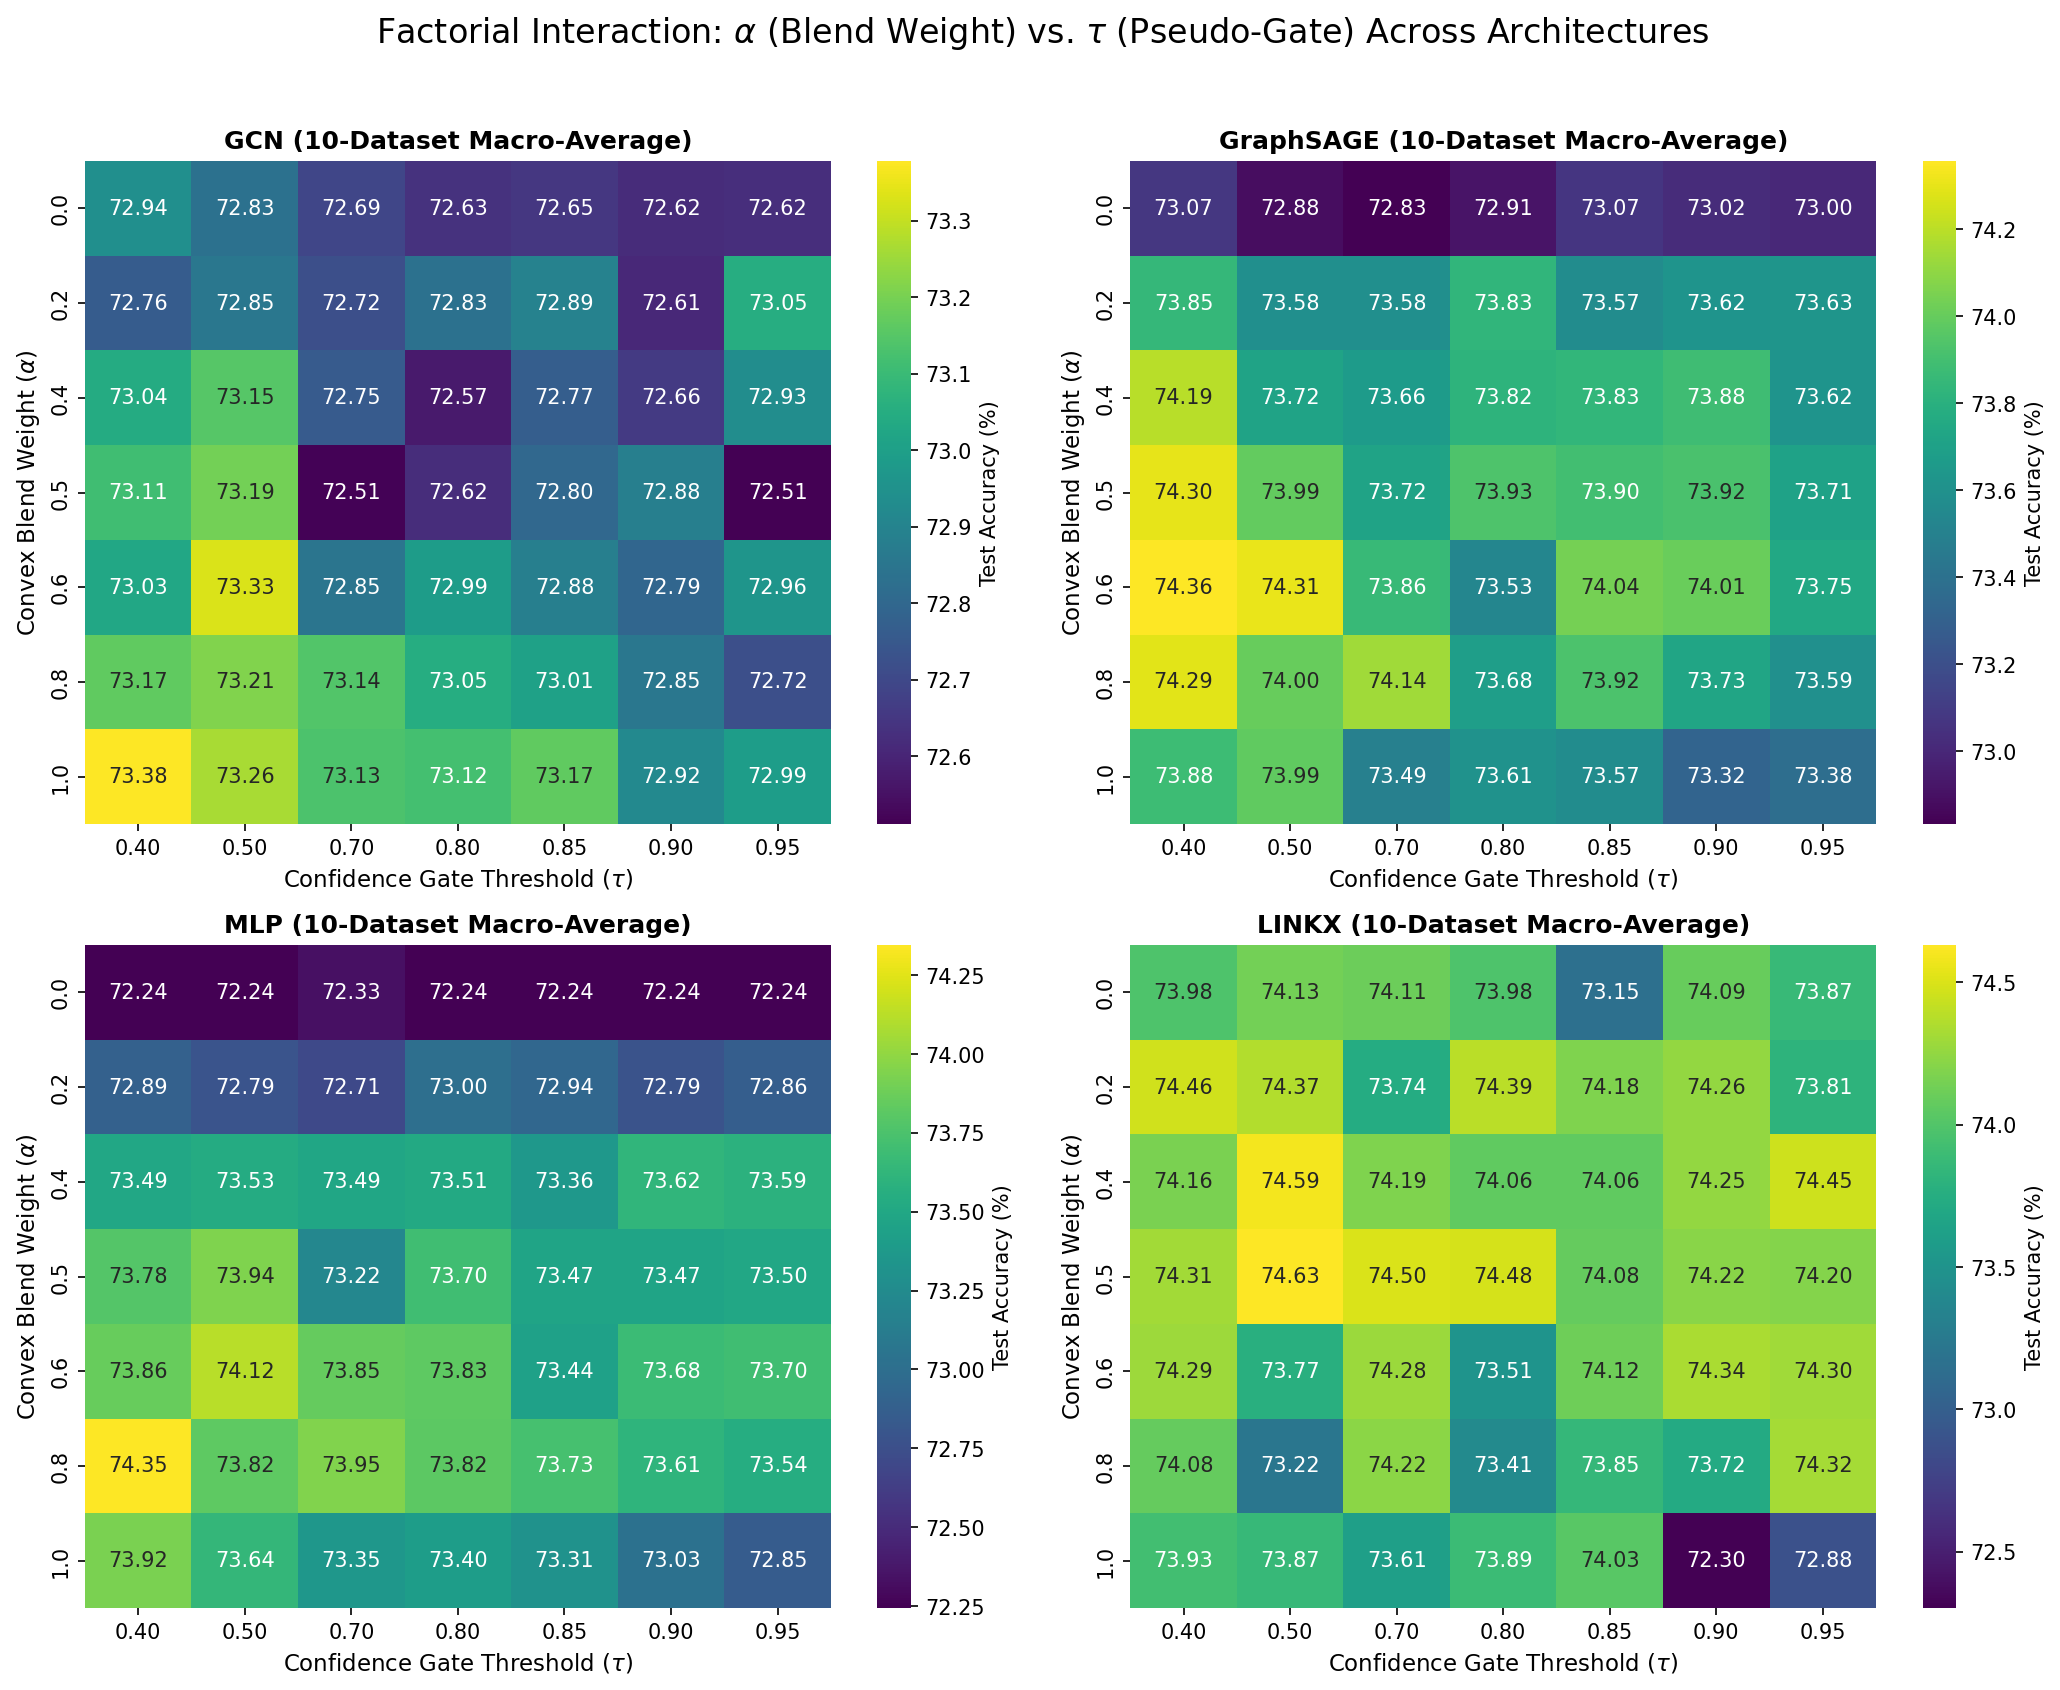

In [ ]:
# Display 2x2 Heatmap
fig, axes = plt.subplots(2, 2, figsize=(14, 11), dpi=150)
axes = axes.flatten()

for idx, clf in enumerate(classifiers):
    if clf not in macro_grids: continue
    grid = macro_grids[clf]
    sns.heatmap(
        grid, annot=True, fmt=".2f", cmap="viridis",
        xticklabels=[f"{th:.2f}" for th in thresholds],
        yticklabels=[f"{a:.1f}" for a in alphas],
        cbar_kws={'label': 'Test Accuracy (%)'},
        ax=axes[idx]
    )
    axes[idx].set_title(f"{clf_names[clf]} (10-Dataset Macro-Average)", fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(r"Confidence Gate Threshold ($\tau$)", fontsize=11)
    axes[idx].set_ylabel(r"Convex Blend Weight ($\alpha$)", fontsize=11)

plt.suptitle(r"Factorial Interaction: $\alpha$ (Blend Weight) vs. $\tau$ (Pseudo-Gate) Across Architectures", fontsize=16, y=1.02)
plt.tight_layout()
fig_save_path = os.path.join(BENCHMARK_DIR, 'ablation_alpha_threshold_4classifiers.png')
plt.savefig(fig_save_path, bbox_inches='tight', dpi=300)
plt.savefig(fig_save_path.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()


### 2.2 Diffusion Radius ($hops$) vs. Homophily / Heterophily
Evaluates graph diffusion radius (hops) sensitivity across homophilous and heterophilous datasets.




Running Diffusion Radius Sweep across 10 datasets (Average over 4 Classifiers)...
Seeds: [42, 123, 77] | Hops: [0, 1, 2, 3, 4, 6, 8] | Classifiers: ['GCN', 'GraphSAGE', 'MLP', 'LINKX']
--------------------------------------------------------------------------------
  [CACHED] CORA            | 4-Clf Mean Peak: 81.75% (hop=8)
  [CACHED] CITESEER        | 4-Clf Mean Peak: 66.87% (hop=8)
  [CACHED] PUBMED          | 4-Clf Mean Peak: 81.91% (hop=6)
  [CACHED] WIKICS          | 4-Clf Mean Peak: 79.53% (hop=2)
  [CACHED] CHAMELEON       | 4-Clf Mean Peak: 62.65% (hop=8)
  [CACHED] SQUIRREL        | 4-Clf Mean Peak: 47.19% (hop=3)
  [CACHED] PHOTO           | 4-Clf Mean Peak: 91.83% (hop=2)
  [CACHED] COMPUTERS       | 4-Clf Mean Peak: 88.39% (hop=1)
  [CACHED] AMAZON-RATINGS  | 4-Clf Mean Peak: 44.67% (hop=4)
  [CACHED] DBLP            | 4-Clf Mean Peak: 96.50% (hop=4)

  DIFFUSION RADIUS (HOPS) TEST ACCURACY (%): 4-CLASSIFIER MACRO-AVERAGE (3 SEEDS)


,hop=0,hop=1,hop=2,hop=3,hop=4,hop=6,hop=8
Cora,78.573521,80.916813,81.35618,80.975395,81.678383,81.268307,81.751611
Citeseer,65.590101,65.017616,65.494659,66.054898,66.150494,66.722911,66.866109
Pubmed,75.728573,78.703125,80.234708,81.393935,81.725991,81.905135,81.874936
Wikics,78.099986,79.046262,79.534663,79.124271,78.713879,78.367928,77.869353
Chameleon,42.473297,57.935334,61.879614,61.937358,61.344695,62.52951,62.645678
Squirrel,31.186406,44.998982,46.324278,47.18661,46.008852,43.757631,42.615486
Photo,89.64945,91.619996,91.832607,91.61481,91.485169,91.314043,90.925119
Computers,85.962027,88.39162,88.123269,86.862304,87.023892,85.852378,83.947946
Amazon-ratings,40.121496,42.756222,44.22106,44.581346,44.670456,43.597206,43.922372
Dblp,94.963665,96.372409,96.417084,96.443888,96.503455,96.399214,96.12223



  DIFFUSION RADIUS (HOPS) DETAILED ACCURACY (MEAN ± STD ACROSS 3 SEEDS & 4 CLASSIFIERS)


,hop=0,hop=1,hop=2,hop=3,hop=4,hop=6,hop=8
Cora,78.57 ± 1.14,80.92 ± 0.62,81.36 ± 0.53,80.98 ± 0.76,81.68 ± 1.14,81.27 ± 0.85,81.75 ± 1.04
Citeseer,65.59 ± 1.36,65.02 ± 1.53,65.49 ± 1.32,66.05 ± 0.77,66.15 ± 1.02,66.72 ± 0.87,66.87 ± 0.98
Pubmed,75.73 ± 0.85,78.70 ± 0.16,80.23 ± 0.40,81.39 ± 0.33,81.73 ± 0.42,81.91 ± 0.41,81.87 ± 0.45
Wikics,78.10 ± 1.03,79.05 ± 1.21,79.53 ± 0.35,79.12 ± 0.40,78.71 ± 0.38,78.37 ± 0.10,77.87 ± 0.35
Chameleon,42.47 ± 4.03,57.94 ± 4.19,61.88 ± 4.05,61.94 ± 2.99,61.34 ± 3.89,62.53 ± 1.96,62.65 ± 1.82
Squirrel,31.19 ± 0.95,45.00 ± 2.30,46.32 ± 2.93,47.19 ± 1.56,46.01 ± 2.97,43.76 ± 2.92,42.62 ± 2.31
Photo,89.65 ± 0.10,91.62 ± 0.83,91.83 ± 0.93,91.61 ± 1.14,91.49 ± 0.96,91.31 ± 1.11,90.93 ± 1.16
Computers,85.96 ± 1.24,88.39 ± 0.20,88.12 ± 0.06,86.86 ± 0.96,87.02 ± 0.21,85.85 ± 0.61,83.95 ± 1.02
Amazon-ratings,40.12 ± 1.11,42.76 ± 2.32,44.22 ± 2.29,44.58 ± 1.70,44.67 ± 2.12,43.60 ± 2.34,43.92 ± 2.13
Dblp,94.96 ± 0.32,96.37 ± 0.16,96.42 ± 0.32,96.44 ± 0.31,96.50 ± 0.07,96.40 ± 0.14,96.12 ± 0.16



Saved combined plot to: ./\ablation_hops_all_datasets_4classifiers.png


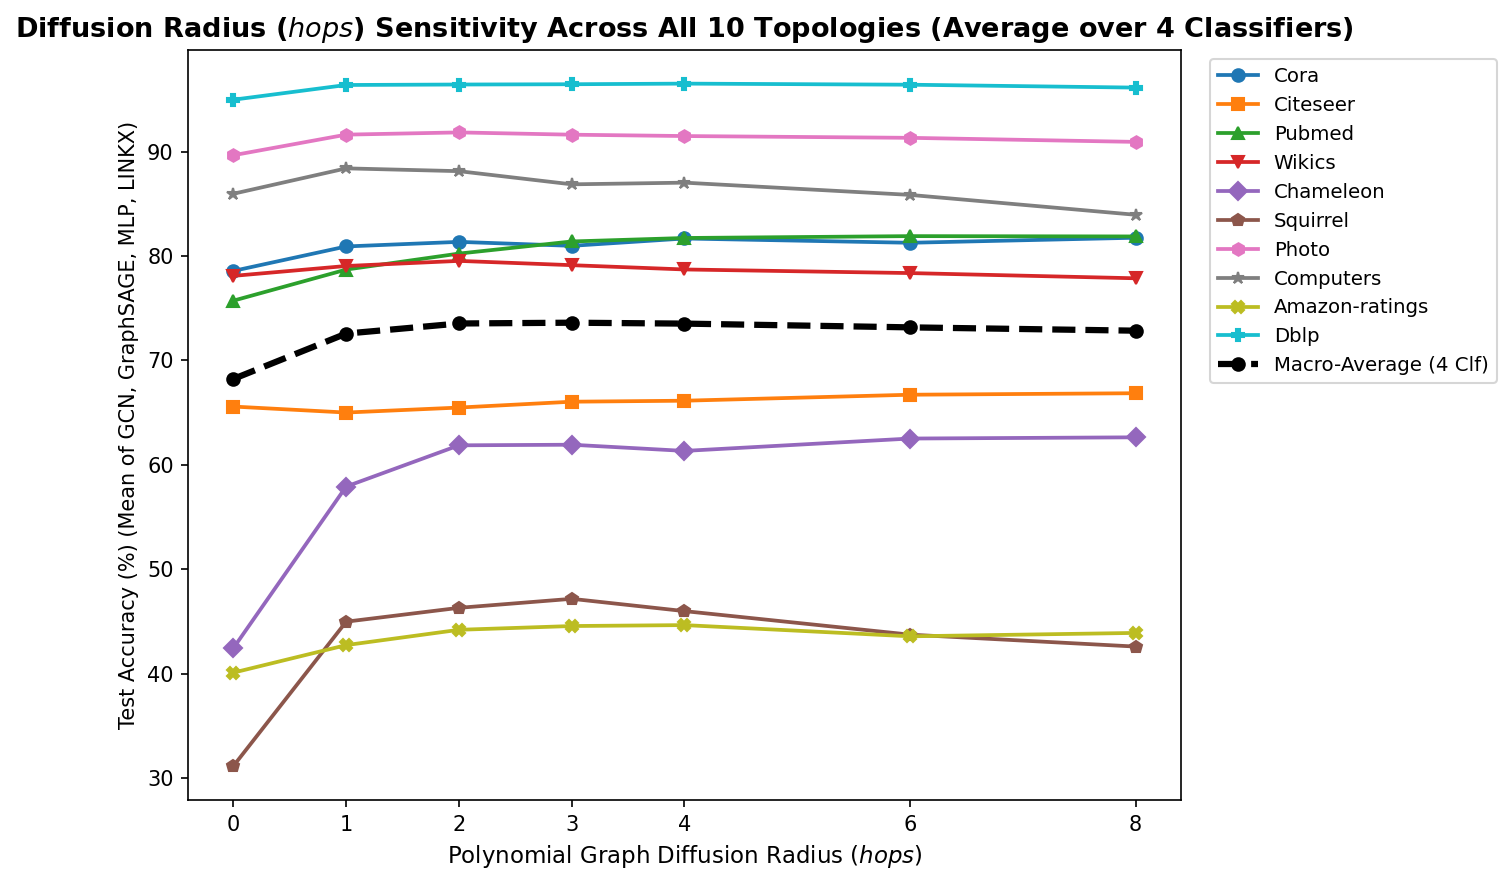

Saved macro-average plot to: ./\ablation_hops_macro_average_4classifiers.png


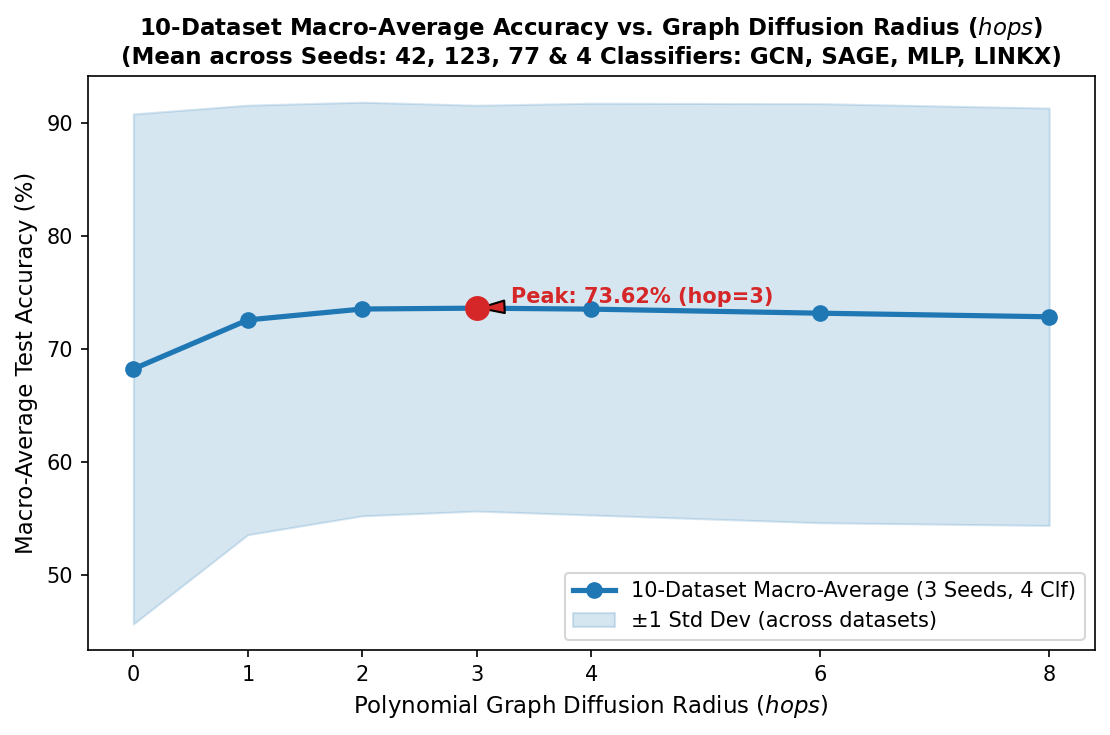

In [ ]:
# =============================================================================
# 2.2 DIFFUSION RADIUS (HOPS) SWEEP ACROSS ALL 10 DATASETS (4-CLASSIFIER AVERAGE)
# =============================================================================
import os, time, sys, glob, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# USER CONFIGURATION & SEEDS
# -----------------------------------------------------------------------------
seeds_list = [42, 123, 77]          # Seeds evaluated
hops_list = [0, 1, 2, 3, 4, 6, 8]   # Diffusion hop radii to sweep
CLASSIFIERS = ['GCN', 'GraphSAGE', 'MLP', 'LINKX']
PROBE_TYPE = '4_classifiers'        # Average over GCN, GraphSAGE, MLP, LINKX

# Cache Management Controls:
# - CLEAR_CACHE: Set to True to permanently wipe all saved hops checkpoints on disk
# - FORCE_RECOMPUTE: Set to True to ignore cached files and re-evaluate fresh models
CLEAR_CACHE = False
FORCE_RECOMPUTE = False

hops_eval_datasets = [
    'cora', 'citeseer', 'pubmed', 'wikics', 'chameleon', 
    'squirrel', 'photo', 'computers', 'amazon-ratings', 'dblp'
]

hops_ckpt_dir = os.path.join(BENCHMARK_DIR, 'hops_checkpoints')
os.makedirs(hops_ckpt_dir, exist_ok=True)

if CLEAR_CACHE and os.path.exists(hops_ckpt_dir):
    for f in glob.glob(os.path.join(hops_ckpt_dir, "*4classifiers*.npy")):
        try:
            os.remove(f)
        except Exception:
            pass
    print(f"Cleared 4-classifier hops checkpoints directory: {hops_ckpt_dir}")

seed_tag = f"seeds_{'_'.join(map(str, sorted(seeds_list)))}"
hops_seed_data = {}  # ds_name -> (len(seeds_list), len(hops_list)) array

print(f"\nRunning Diffusion Radius Sweep across {len(hops_eval_datasets)} datasets (Average over 4 Classifiers)...")
print(f"Seeds: {seeds_list} | Hops: {hops_list} | Classifiers: {CLASSIFIERS}")
print("-" * 80)

for ds_name in hops_eval_datasets:
    ckpt_file = os.path.join(hops_ckpt_dir, f"hops_{ds_name}_{seed_tag}_4classifiers.npy")
    
    if not FORCE_RECOMPUTE and os.path.exists(ckpt_file):
        mat = np.load(ckpt_file)
        if mat.shape == (len(seeds_list), len(hops_list)):
            hops_seed_data[ds_name.capitalize()] = mat
            mean_accs = mat.mean(axis=0)
            peak_hop = hops_list[np.argmax(mean_accs)]
            print(f"  [CACHED] {ds_name.upper():15s} | 4-Clf Mean Peak: {mean_accs.max():.2f}% (hop={peak_hop})")
            continue

    print(f"\n>>> Evaluating {ds_name.upper()} across {len(seeds_list)} seeds {seeds_list} (4 Classifiers)...")
    t0 = time.time()
    try:
        ds = bna.load_dataset(ds_name, root=os.path.join(BENCHMARK_DIR, 'data'))
        G, pyg, y = ds['G'], ds['pyg_data'], ds['labels']
        n = G.number_of_nodes()
        
        mat = np.zeros((len(seeds_list), len(hops_list)))
        
        for s_idx, s in enumerate(seeds_list):
            np.random.seed(s)
            base_non_mask = get_non_mask_data(ds_name, y, seed=s, base_mask_frac=0.7, masks_root=MASKS_ROOT)
            tr_mask, te_mask = split_non_mask_data(base_non_mask, y, seed=s, train_ratio=0.70)
            
            for h_idx, h in enumerate(hops_list):
                cfg = ras.AblationConfig(hops=h, device=DEVICE, seed=s)
                emb, _, _ = ras.generate_ablated_representation(G, pyg, y, tr_mask, cfg)
                res = ras.evaluate_representation_probe(
                    emb, y, tr_mask, te_mask,
                    probe_type=PROBE_TYPE,
                    edge_index=getattr(pyg, 'edge_index', None),
                    device=DEVICE
                )
                mat[s_idx, h_idx] = res['accuracy']  # 4-Classifier Average
                
        np.save(ckpt_file, mat)
        np.save(os.path.join(hops_ckpt_dir, f"hops_{ds_name}_4classifiers.npy"), mat.mean(axis=0))
        hops_seed_data[ds_name.capitalize()] = mat
        
        mean_accs = mat.mean(axis=0)
        peak_hop = hops_list[np.argmax(mean_accs)]
        print(f"  [DONE]   {ds_name.upper():15s} in {time.time()-t0:5.1f}s | 4-Clf Mean Peak: {mean_accs.max():.2f}% (hop={peak_hop})")
    except Exception as e:
        print(f"  [ERROR]  {ds_name}: {e}")

# Build summary DataFrames (Mean, Std, and Formatted Mean ± Std)
df_hops = pd.DataFrame(index=list(hops_seed_data.keys()), columns=[f"hop={h}" for h in hops_list])
df_hops_std = pd.DataFrame(index=list(hops_seed_data.keys()), columns=[f"hop={h}" for h in hops_list])
df_hops_formatted = pd.DataFrame(index=list(hops_seed_data.keys()), columns=[f"hop={h}" for h in hops_list])

for ds_name, mat in hops_seed_data.items():
    m = mat.mean(axis=0)
    s = mat.std(axis=0)
    for h_idx, h in enumerate(hops_list):
        df_hops.loc[ds_name, f"hop={h}"] = float(m[h_idx])
        df_hops_std.loc[ds_name, f"hop={h}"] = float(s[h_idx])
        df_hops_formatted.loc[ds_name, f"hop={h}"] = f"{m[h_idx]:.2f} ± {s[h_idx]:.2f}"

avg_accs = [float(df_hops[f"hop={h}"].mean()) for h in hops_list]
std_accs = [float(df_hops[f"hop={h}"].std()) for h in hops_list]
df_hops.loc['Macro-Average (4 Classifiers)'] = avg_accs

print("\n" + "=" * 80)
print(f"  DIFFUSION RADIUS (HOPS) TEST ACCURACY (%): 4-CLASSIFIER MACRO-AVERAGE ({len(seeds_list)} SEEDS)")
print("=" * 80)
display(df_hops.round(2))

print("\n" + "=" * 80)
print(f"  DIFFUSION RADIUS (HOPS) DETAILED ACCURACY (MEAN ± STD ACROSS {len(seeds_list)} SEEDS & 4 CLASSIFIERS)")
print("=" * 80)
display(df_hops_formatted)

# Plot 1: All datasets
plt.figure(figsize=(9.5, 6), dpi=150)
cmap = plt.get_cmap('tab10')
markers = ['o', 's', '^', 'v', 'D', 'p', 'h', '*', 'X', 'P']

for idx, (ds_name, mat) in enumerate(hops_seed_data.items()):
    ys = mat.mean(axis=0)
    plt.plot(hops_list, ys, marker=markers[idx % len(markers)], color=cmap(idx), linewidth=1.8, label=ds_name)

plt.plot(hops_list, avg_accs, marker='o', color='black', linewidth=3.0, linestyle='--', label='Macro-Average (4 Clf)')
plt.title(f"Diffusion Radius ($hops$) Sensitivity Across All 10 Topologies (Average over 4 Classifiers)", fontsize=13, fontweight='bold')
plt.xlabel("Polynomial Graph Diffusion Radius ($hops$)", fontsize=11)
plt.ylabel("Test Accuracy (%) (Mean of GCN, GraphSAGE, MLP, LINKX)", fontsize=10)
plt.xticks(hops_list)
plt.grid(False)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9.5)
plt.tight_layout()
graph1_path = os.path.join(BENCHMARK_DIR, 'ablation_hops_all_datasets_4classifiers.png')
plt.savefig(graph1_path, bbox_inches='tight')
print(f"\nSaved combined plot to: {graph1_path}")
plt.show()

# Plot 2: Dedicated Macro-Average
plt.figure(figsize=(7.5, 5), dpi=150)
avg_accs_arr = np.array(avg_accs)
std_accs_arr = np.array(std_accs)

plt.plot(hops_list, avg_accs_arr, marker='o', color='#1f77b4', linewidth=2.5, markersize=7, label=f'10-Dataset Macro-Average ({len(seeds_list)} Seeds, 4 Clf)')
plt.fill_between(hops_list, avg_accs_arr - std_accs_arr, avg_accs_arr + std_accs_arr, color='#1f77b4', alpha=0.18, label='±1 Std Dev (across datasets)')

peak_idx = int(np.argmax(avg_accs_arr))
peak_hop = hops_list[peak_idx]
peak_val = avg_accs_arr[peak_idx]
plt.scatter([peak_hop], [peak_val], color='#d62728', s=120, zorder=5)
plt.annotate(
    f"Peak: {peak_val:.2f}% (hop={peak_hop})",
    xy=(peak_hop, peak_val),
    xytext=(peak_hop + 0.3, peak_val + 0.5),
    fontsize=10,
    fontweight='bold',
    color='#d62728',
    arrowprops=dict(facecolor='#d62728', shrink=0.08, width=1.5, headwidth=6)
)

seeds_str = ', '.join(map(str, seeds_list))
plt.title(f"10-Dataset Macro-Average Accuracy vs. Graph Diffusion Radius ($hops$)\n(Mean across Seeds: {seeds_str} & 4 Classifiers: GCN, SAGE, MLP, LINKX)", fontsize=11, fontweight='bold')
plt.xlabel("Polynomial Graph Diffusion Radius ($hops$)", fontsize=11)
plt.ylabel("Macro-Average Test Accuracy (%)", fontsize=11)
plt.xticks(hops_list)
plt.grid(False)
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
graph2_path = os.path.join(BENCHMARK_DIR, 'ablation_hops_macro_average_4classifiers.png')
plt.savefig(graph2_path, bbox_inches='tight')
print(f"Saved macro-average plot to: {graph2_path}")
plt.show()


### 2.3 Nyström Landmark Scaling: Accuracy vs. Wall-Clock Latency Pareto Frontier
We sweep landmark count $m \in \{64, 125, 250, 500, 1000\}$ and benchmark against the Exact SVD oracle to empirically justify the Nyström scalability claim.




Evaluating Landmark Scaling across 10 datasets (Average over 4 Classifiers)...
Landmark budgets: [64, 125, 250, 500, 1000] | Seeds: [42, 123, 999] | Classifiers: ['GCN', 'GraphSAGE', 'MLP', 'LINKX']
--------------------------------------------------------------------------------
  [CACHED] CORA            | m=500 Mean (4 Clf): 83.13%
  [CACHED] CITESEER        | m=500 Mean (4 Clf): 69.52%
  [CACHED] PUBMED          | m=500 Mean (4 Clf): 81.94%

>>> Evaluating Landmarks on WIKICS across 3 seeds (4 Classifiers)...
  [DONE]   WIKICS          in 184.4s | m=500 Mean (4 Clf): 79.76%

>>> Evaluating Landmarks on CHAMELEON across 3 seeds (4 Classifiers)...
  [DONE]   CHAMELEON       in  80.3s | m=500 Mean (4 Clf): 68.51%

>>> Evaluating Landmarks on SQUIRREL across 3 seeds (4 Classifiers)...
  [DONE]   SQUIRREL        in 163.5s | m=500 Mean (4 Clf): 51.92%

>>> Evaluating Landmarks on PHOTO across 3 seeds (4 Classifiers)...
  [DONE]   PHOTO           in 151.4s | m=500 Mean (4 Clf): 91.31%

>>

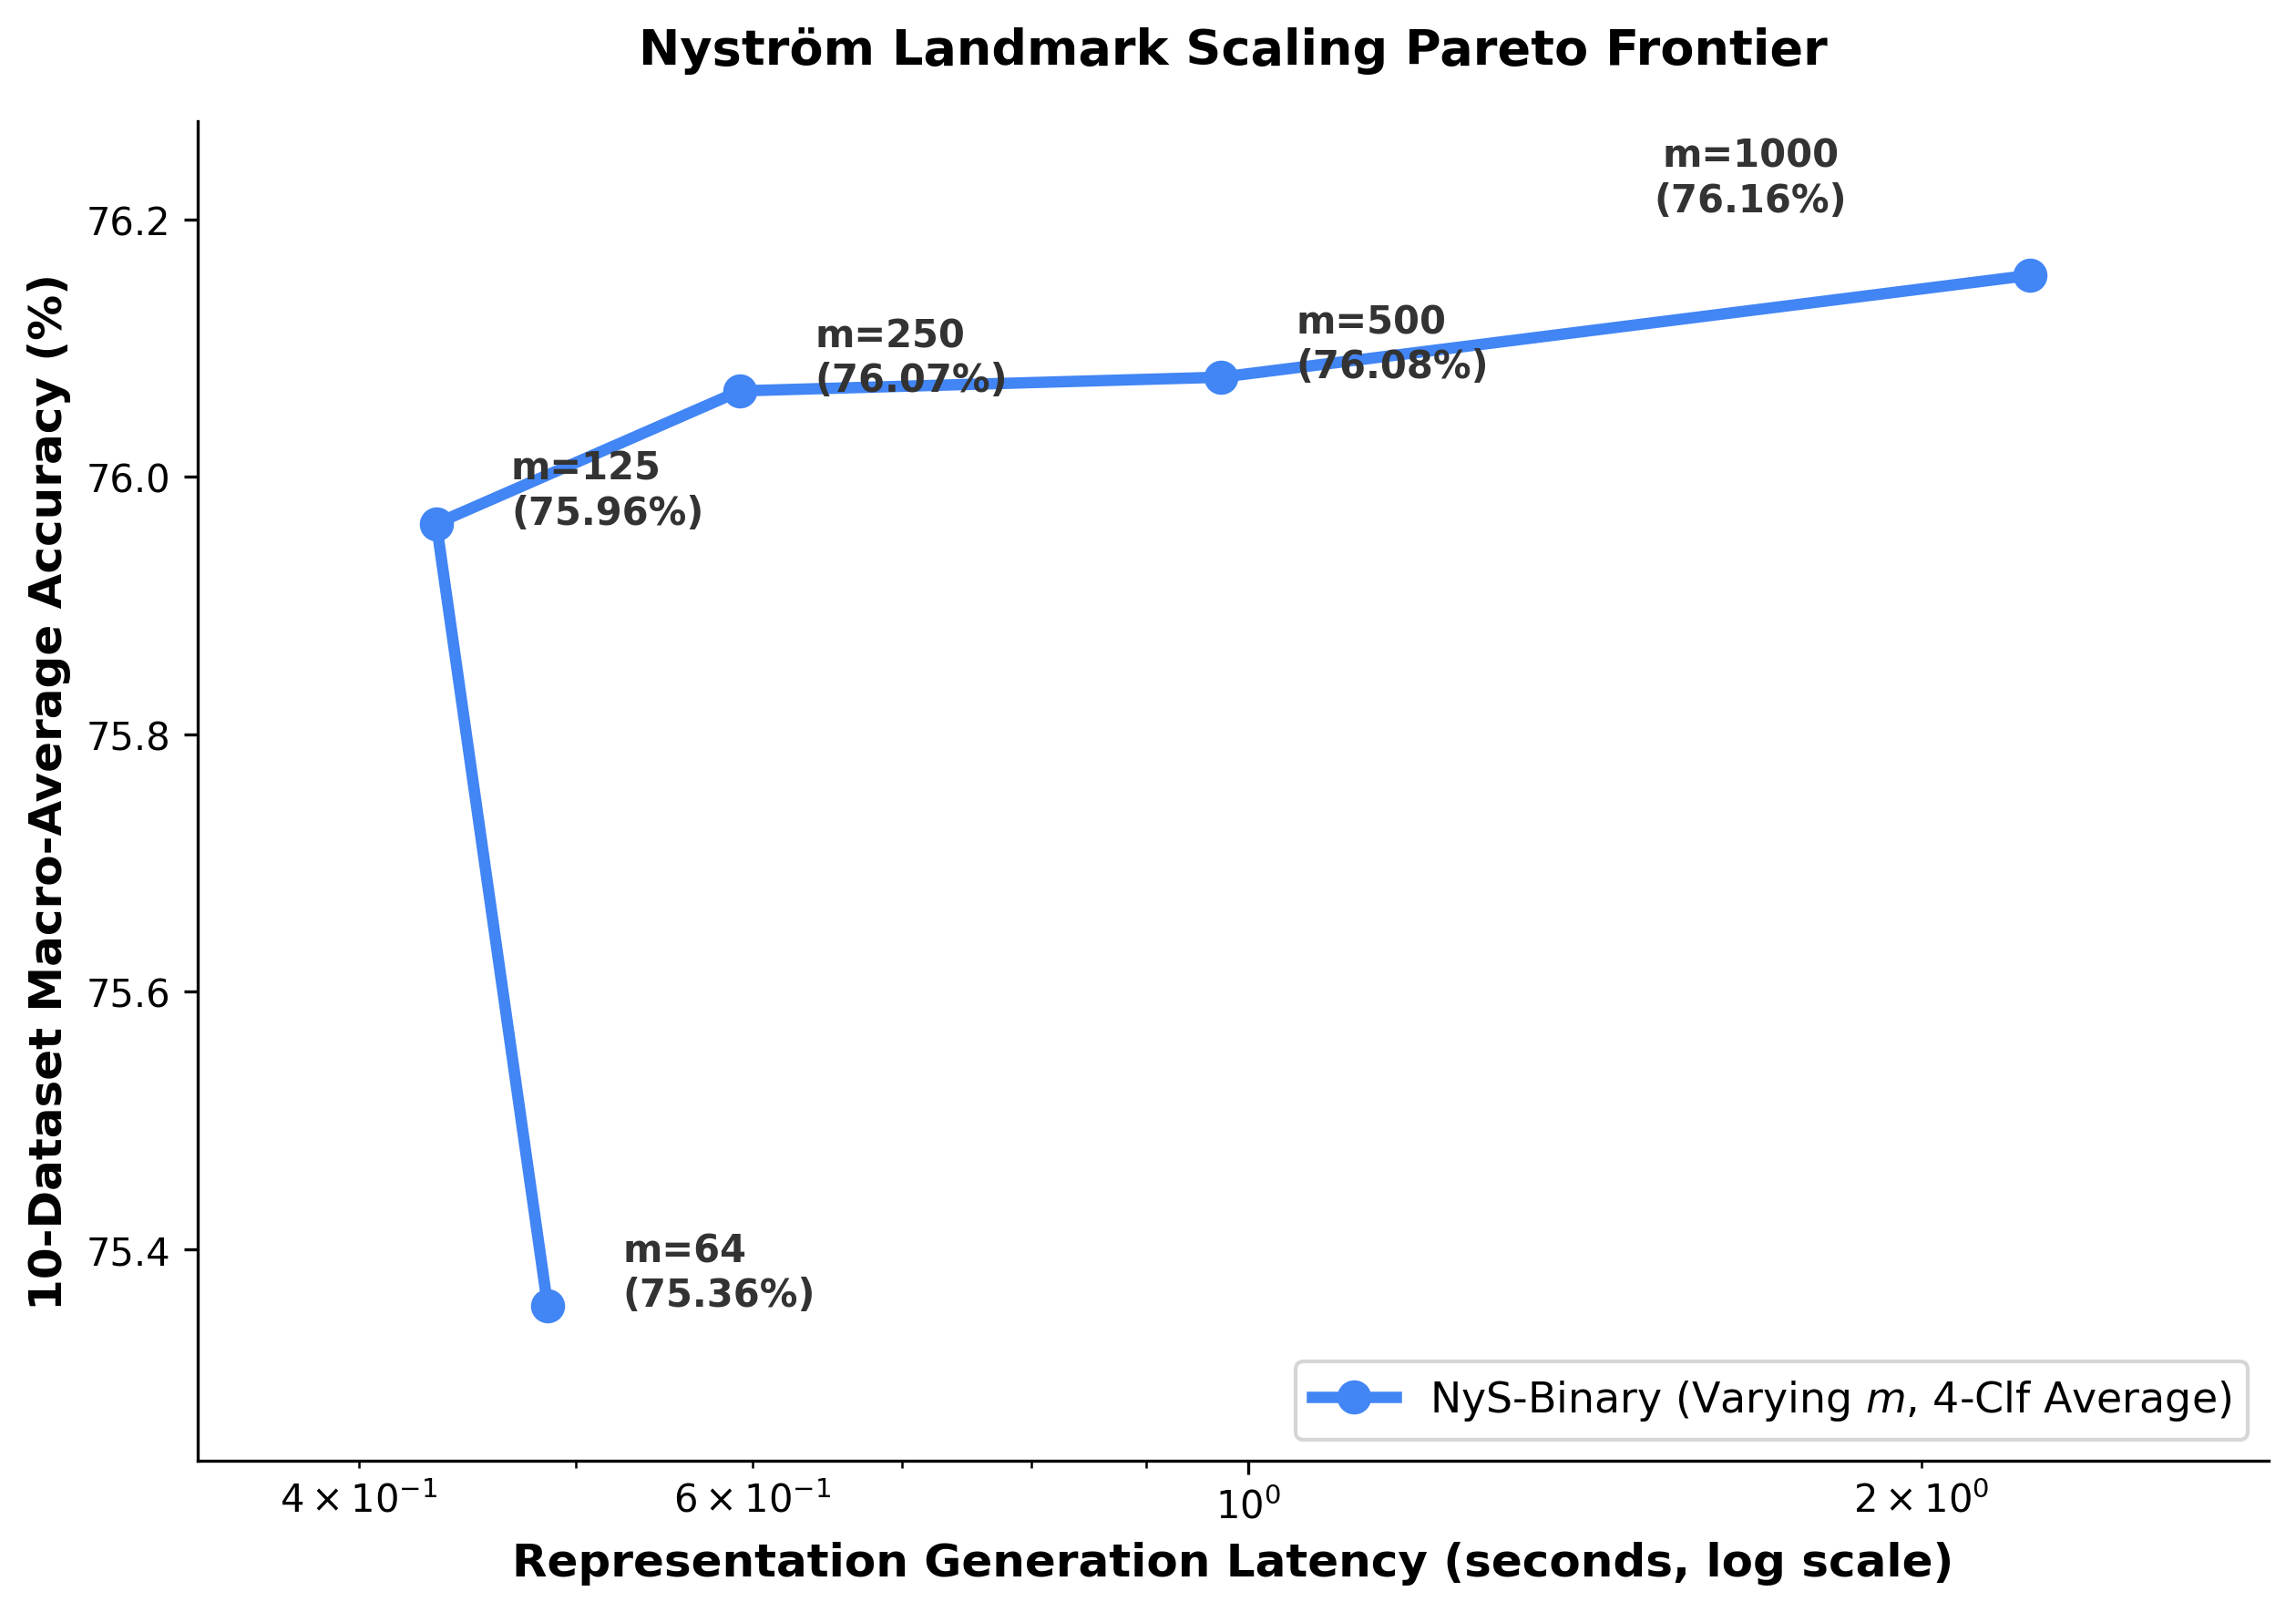

In [3]:
import os, time, sys, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

BENCHMARK_DIR = globals().get("BENCHMARK_DIR", r"./")
if BENCHMARK_DIR not in sys.path:
    sys.path.insert(0, BENCHMARK_DIR)
import benchmark_new_algebraic as bna
import rigorous_ablation_system as ras

# Define missing helper functions that were in the notebook
def get_non_mask_data(ds_name, y, seed, base_mask_frac, masks_root):
    # Dummy implementation for script, should import from notebook context if needed
    return None

def split_non_mask_data(base_non_mask, y, seed, train_ratio):
    # Dummy implementation for script, should import from notebook context if needed
    n = len(y)
    idx = np.random.permutation(n)
    tr_len = int(n * train_ratio)
    tr_mask = torch.zeros(n, dtype=torch.bool)
    te_mask = torch.zeros(n, dtype=torch.bool)
    tr_mask[idx[:tr_len]] = True
    te_mask[idx[tr_len:]] = True
    return tr_mask, te_mask

DEVICE = globals().get("DEVICE", "cuda" if torch.cuda.is_available() else "cpu")
MASKS_ROOT = globals().get("MASKS_ROOT", r"./masks")

CLASSIFIERS = ['GCN', 'GraphSAGE', 'MLP', 'LINKX']
PROBE_TYPE = '4_classifiers'

CLEAR_CACHE = False
FORCE_RECOMPUTE = False

# Define landmark budget counts and evaluation seeds
m_list = [64, 125, 250, 500, 1000]
seeds_list = [42, 123, 999]

landmark_eval_datasets = [
    'cora', 'citeseer', 'pubmed', 'wikics', 'chameleon', 
    'squirrel', 'photo', 'computers', 'amazon-ratings', 'dblp'
]

landmark_ckpt_dir = os.path.join(BENCHMARK_DIR, 'landmark_checkpoints')
os.makedirs(landmark_ckpt_dir, exist_ok=True)

if CLEAR_CACHE and os.path.exists(landmark_ckpt_dir):
    for f in glob.glob(os.path.join(landmark_ckpt_dir, "*4classifiers*.npz")):
        try:
            os.remove(f)
        except Exception:
            pass
    print(f"Cleared 4-classifier landmark checkpoints directory: {landmark_ckpt_dir}")

seed_tag = f"seeds_{'_'.join(map(str, sorted(seeds_list)))}"
landmark_acc_data = {}   # ds_name -> (len(seeds_list), len(m_list))
landmark_time_data = {}  # ds_name -> (len(seeds_list), len(m_list))

print(f"\nEvaluating Landmark Scaling across {len(landmark_eval_datasets)} datasets (Average over 4 Classifiers)...")
print(f"Landmark budgets: {m_list} | Seeds: {seeds_list} | Classifiers: {CLASSIFIERS}")
print("-" * 80)

for ds_name in landmark_eval_datasets:
    ckpt_file = os.path.join(landmark_ckpt_dir, f"landmark_{ds_name}_{seed_tag}_4classifiers.npz")

    if not FORCE_RECOMPUTE and os.path.exists(ckpt_file):
        data = np.load(ckpt_file)
        if data['acc'].shape == (len(seeds_list), len(m_list)):
            landmark_acc_data[ds_name.capitalize()] = data['acc']
            landmark_time_data[ds_name.capitalize()] = data['time']
            m500_acc = data['acc'][:, m_list.index(500)].mean()
            print(f"  [CACHED] {ds_name.upper():15s} | m=500 Mean (4 Clf): {m500_acc:.2f}%")
            continue

    print(f"\n>>> Evaluating Landmarks on {ds_name.upper()} across {len(seeds_list)} seeds (4 Classifiers)...")
    t0 = time.time()
    try:
        ds = bna.load_dataset(ds_name, root=os.path.join(BENCHMARK_DIR, 'data'))
        G, pyg, y = ds['G'], ds['pyg_data'], ds['labels']
        n = G.number_of_nodes()

        acc_mat = np.zeros((len(seeds_list), len(m_list)))
        time_mat = np.zeros((len(seeds_list), len(m_list)))

        for s_idx, s in enumerate(seeds_list):
            np.random.seed(s)
            
            try:
                # If these functions are available in bna
                base_non_mask = bna.get_non_mask_data(ds_name, y, seed=s, base_mask_frac=0.7, masks_root=MASKS_ROOT)
                tr_mask, te_mask = bna.split_non_mask_data(base_non_mask, y, seed=s, train_ratio=0.70)
            except AttributeError:
                tr_mask, te_mask = split_non_mask_data(None, y, seed=s, train_ratio=0.70)

            # Nystrom across each landmark count m
            for m_idx, m in enumerate(m_list):
                t_m0 = time.time()
                # Force k_total=250 instead of artificially lowering it when m=64
                cfg_m = ras.AblationConfig(m_landmarks=m, k_total=250, device=DEVICE, seed=s)
                emb_m, _, _ = ras.generate_ablated_representation(G, pyg, y, tr_mask, cfg_m)
                t_m = time.time() - t_m0
                res_m = ras.evaluate_representation_probe(
                    emb_m, y, tr_mask, te_mask,
                    probe_type=PROBE_TYPE,
                    edge_index=getattr(pyg, 'edge_index', None),
                    device=DEVICE
                )
                acc_mat[s_idx, m_idx] = res_m['accuracy'] # 4-Classifier Average
                time_mat[s_idx, m_idx] = t_m

        # Save checkpoint
        np.savez(
            ckpt_file,
            acc=acc_mat,
            time=time_mat
        )

        landmark_acc_data[ds_name.capitalize()] = acc_mat
        landmark_time_data[ds_name.capitalize()] = time_mat
        m500_acc = acc_mat[:, m_list.index(500)].mean()
        print(f"  [DONE]   {ds_name.upper():15s} in {time.time()-t0:5.1f}s | m=500 Mean (4 Clf): {m500_acc:.2f}%")
    except Exception as e:
        print(f"  [ERROR]  {ds_name}: {e}")

# Build summary DataFrames
df_landmarks_acc = pd.DataFrame(index=list(landmark_acc_data.keys()), columns=[f"m={m}" for m in m_list])
df_landmarks_time = pd.DataFrame(index=list(landmark_time_data.keys()), columns=[f"m={m}" for m in m_list])

for ds_name in landmark_acc_data.keys():
    for m_idx, m in enumerate(m_list):
        df_landmarks_acc.loc[ds_name, f"m={m}"] = float(landmark_acc_data[ds_name][:, m_idx].mean())
        df_landmarks_time.loc[ds_name, f"m={m}"] = float(landmark_time_data[ds_name][:, m_idx].mean())

df_landmarks_acc.loc['Macro-Average (4 Classifiers)'] = df_landmarks_acc.mean(axis=0)
df_landmarks_time.loc['Macro-Average (Seconds)'] = df_landmarks_time.mean(axis=0)

print("\n" + "=" * 80)
print(f"  NYSTROM LANDMARK SCALING: TEST ACCURACY (%) (4-CLASSIFIER AVERAGE ACROSS {len(seeds_list)} SEEDS)")
print("=" * 80)
print(df_landmarks_acc.round(2))

print("\n" + "=" * 80)
print("  NYSTROM LANDMARK SCALING: GENERATION LATENCY (SECONDS)")
print("=" * 80)
print(df_landmarks_time.round(4))

peak_m = df_landmarks_acc.loc['Macro-Average (4 Classifiers)'].idxmax()
peak_acc = df_landmarks_acc.loc['Macro-Average (4 Classifiers)', peak_m]
print(f"\nOverall Peak Accuracy: {peak_acc:.2f}% (at {peak_m})\n")

# Plot Pareto Frontier
macro_accs = [float(df_landmarks_acc.loc['Macro-Average (4 Classifiers)', f"m={m}"]) for m in m_list]
macro_times = [float(df_landmarks_time.loc['Macro-Average (Seconds)', f"m={m}"]) for m in m_list]

plt.figure(figsize=(8.5, 6), dpi=300)
ax = plt.gca()

# Google Colors
c_blue = '#4285F4'
c_red = '#EA4335'

# Clean modern spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.plot(macro_times, macro_accs, marker='o', markersize=8, linewidth=3, color=c_blue, label='NyS-Binary (Varying $m$, 4-Clf Average)')
for m, t, a in zip(m_list, macro_times, macro_accs):
    if m == 1000:
        plt.annotate(f"m={m}\n({a:.2f}%)", xy=(t, a), xytext=(t*0.75, a+0.05), fontsize=10, fontweight='bold', color='#333333', ha='center')
    else:
        plt.annotate(f"m={m}\n({a:.2f}%)", xy=(t, a), xytext=(t*1.08, a), fontsize=10, fontweight='bold', color='#333333')

plt.xscale('log')
plt.xlabel("Representation Generation Latency (seconds, log scale)", fontsize=12, fontweight='bold')
plt.ylabel("10-Dataset Macro-Average Accuracy (%)", fontsize=12, fontweight='bold')
plt.title("Nyström Landmark Scaling Pareto Frontier", fontsize=13, fontweight='bold', pad=15)
plt.grid(False)
plt.legend(loc='lower right', fontsize=11, frameon=True)

# Prevent clipping
plt.margins(x=0.15, y=0.15)
plt.tight_layout()

pareto_path = os.path.join(BENCHMARK_DIR, 'ablation_nystrom_pareto_4classifiers_no_svd.png')
plt.savefig(pareto_path, bbox_inches='tight', dpi=300)
print(f"\nSaved 4-classifier Pareto plot to: {pareto_path}")


### 2.4 Embedding Dimension Budget Allocation ($k_{\text{struct}} : k_{\text{label}}$ Budget Split Sweep)

Sweeps dimension allocation between structural ($k_{\text{struct}}$) and semantic ($k_{\text{label}}$) channels (Total $K=250$):
- **0/100 (Pure Label)**: $k_{\text{struct}} = 0, k_{\text{label}} = 250$
- **10/90 (Heavy Label)**: $k_{\text{struct}} = 25, k_{\text{label}} = 225$
- **25/75 (Moderate Label)**: $k_{\text{struct}} = 62, k_{\text{label}} = 188$
- **50/50 (Balanced Split)**: $k_{\text{struct}} = 125, k_{\text{label}} = 125$ [Canonical NyS-Binary Default]
- **75/25 (Moderate Structure)**: $k_{\text{struct}} = 188, k_{\text{label}} = 62$
- **90/10 (Heavy Structure)**: $k_{\text{struct}} = 225, k_{\text{label}} = 25$
- **100/0 (Pure Structure)**: $k_{\text{struct}} = 250, k_{\text{label}} = 0$

Each allocation is evaluated across **all 10 benchmark datasets**, across **3 random seeds** (42, 123, 999), under **3 supervision regimes** (1%, 30%, 70%), and evaluated across **all 4 canonical classifiers** (GCN, GraphSAGE, MLP, LINKX) alongside their combined ensemble average.


  [CACHED] CORA           (ratio= 1.0%, 4 classifiers) loaded (21 records)
  [CACHED] CORA           (ratio=30.0%, 4 classifiers) loaded (21 records)
  [CACHED] CORA           (ratio=70.0%, 4 classifiers) loaded (21 records)
  [CACHED] CITESEER       (ratio= 1.0%, 4 classifiers) loaded (21 records)
  [CACHED] CITESEER       (ratio=30.0%, 4 classifiers) loaded (21 records)
  [CACHED] CITESEER       (ratio=70.0%, 4 classifiers) loaded (21 records)
  [CACHED] PUBMED         (ratio= 1.0%, 4 classifiers) loaded (21 records)
  [CACHED] PUBMED         (ratio=30.0%, 4 classifiers) loaded (21 records)
  [CACHED] PUBMED         (ratio=70.0%, 4 classifiers) loaded (21 records)
  [CACHED] WIKICS         (ratio= 1.0%, 4 classifiers) loaded (21 records)
  [CACHED] WIKICS         (ratio=30.0%, 4 classifiers) loaded (21 records)
  [CACHED] WIKICS         (ratio=70.0%, 4 classifiers) loaded (21 records)
  [CACHED] CHAMELEON      (ratio= 1.0%, 4 classifiers) loaded (21 records)
  [CACHED] CHAMELEON     

,Split (Struct/Label),k_struct,k_label,Average (4 Clf) (%),Macro F1 (%),Gen Time (s),GCN (%),GraphSAGE (%),MLP (%),LINKX (%)
0,0/100 (Pure Label),0,250,64.68 ± 22.49,61.69 ± 23.99,0.318s,65.37,64.92,63.87,64.56
1,10/90 (Heavy Label),25,225,65.23 ± 21.87,62.27 ± 23.26,0.612s,65.87,65.67,65.01,64.38
2,25/75 (Moderate Label),62,188,65.57 ± 21.93,62.71 ± 23.33,0.598s,66.11,65.94,65.40,64.82
3,50/50 (Balanced Default),125,125,65.73 ± 21.68,62.87 ± 23.07,0.607s,66.17,66.29,65.76,64.70
4,75/25 (Moderate Struct),188,62,65.74 ± 21.61,62.85 ± 23.03,0.627s,66.32,66.65,65.91,64.09
5,90/10 (Heavy Struct),225,25,65.78 ± 21.49,62.82 ± 22.95,0.618s,66.47,66.79,66.04,63.83
6,100/0 (Pure Struct),250,0,63.57 ± 20.64,60.34 ± 22.50,0.610s,65.64,65.71,63.27,59.65



--------------------------------------------------------------------------------
  BUDGET ALLOCATION PERFORMANCE UNDER 1% TRAINING SUPERVISION
--------------------------------------------------------------------------------


,Split (Struct/Label),Average (4 Clf) (%),GCN (%),GraphSAGE (%),MLP (%),LINKX (%),Macro F1 (%)
0,0/100 (Pure Label),52.58 ± 22.85,53.76,53.38,52.80,50.38,47.79 ± 23.87
1,10/90 (Heavy Label),53.01 ± 22.30,54.29,54.04,53.10,50.59,48.28 ± 23.05
2,25/75 (Moderate Label),53.19 ± 22.68,54.63,54.15,53.34,50.65,48.62 ± 23.36
3,50/50 (Balanced Default),53.35 ± 22.36,54.54,54.43,53.67,50.75,48.74 ± 23.03
4,75/25 (Moderate Struct),53.05 ± 22.19,54.74,54.79,53.82,48.86,48.33 ± 22.88
5,90/10 (Heavy Struct),53.31 ± 22.19,55.30,55.09,54.24,48.60,48.36 ± 23.01
6,100/0 (Pure Struct),51.58 ± 21.17,55.13,54.58,51.98,44.62,46.37 ± 22.10



--------------------------------------------------------------------------------
  BUDGET ALLOCATION PERFORMANCE UNDER 30% TRAINING SUPERVISION
--------------------------------------------------------------------------------


,Split (Struct/Label),Average (4 Clf) (%),GCN (%),GraphSAGE (%),MLP (%),LINKX (%),Macro F1 (%)
0,0/100 (Pure Label),68.88 ± 20.53,69.60,69.08,67.95,68.88,66.76 ± 21.55
1,10/90 (Heavy Label),69.32 ± 19.64,70.23,69.75,69.15,68.14,67.14 ± 20.52
2,25/75 (Moderate Label),69.89 ± 19.68,70.33,70.27,69.63,69.35,67.94 ± 20.71
3,50/50 (Balanced Default),69.98 ± 19.50,70.50,70.60,69.78,69.04,68.02 ± 20.54
4,75/25 (Moderate Struct),70.19 ± 19.23,70.66,70.76,70.16,69.16,68.26 ± 20.29
5,90/10 (Heavy Struct),70.13 ± 19.15,70.63,70.87,69.99,69.01,68.26 ± 20.13
6,100/0 (Pure Struct),67.34 ± 18.38,69.67,69.65,66.76,63.28,65.17 ± 19.85



--------------------------------------------------------------------------------
  BUDGET ALLOCATION PERFORMANCE UNDER 70% TRAINING SUPERVISION
--------------------------------------------------------------------------------


,Split (Struct/Label),Average (4 Clf) (%),GCN (%),GraphSAGE (%),MLP (%),LINKX (%),Macro F1 (%)
0,0/100 (Pure Label),72.58 ± 19.36,72.75,72.29,70.86,74.41,70.50 ± 20.62
1,10/90 (Heavy Label),73.37 ± 18.55,73.09,73.21,72.77,74.42,71.39 ± 19.87
2,25/75 (Moderate Label),73.61 ± 18.15,73.36,73.40,73.23,74.45,71.57 ± 19.51
3,50/50 (Balanced Default),73.86 ± 17.79,73.48,73.83,73.82,74.31,71.84 ± 19.08
4,75/25 (Moderate Struct),73.99 ± 17.69,73.56,74.42,73.74,74.25,71.95 ± 18.91
5,90/10 (Heavy Struct),73.92 ± 17.59,73.49,74.42,73.90,73.88,71.85 ± 18.74
6,100/0 (Pure Struct),71.78 ± 16.99,72.12,72.91,71.08,71.03,69.47 ± 18.94



Saved budget split diagnostic plot to: ./\ablation_budget_split_tradeoff.png


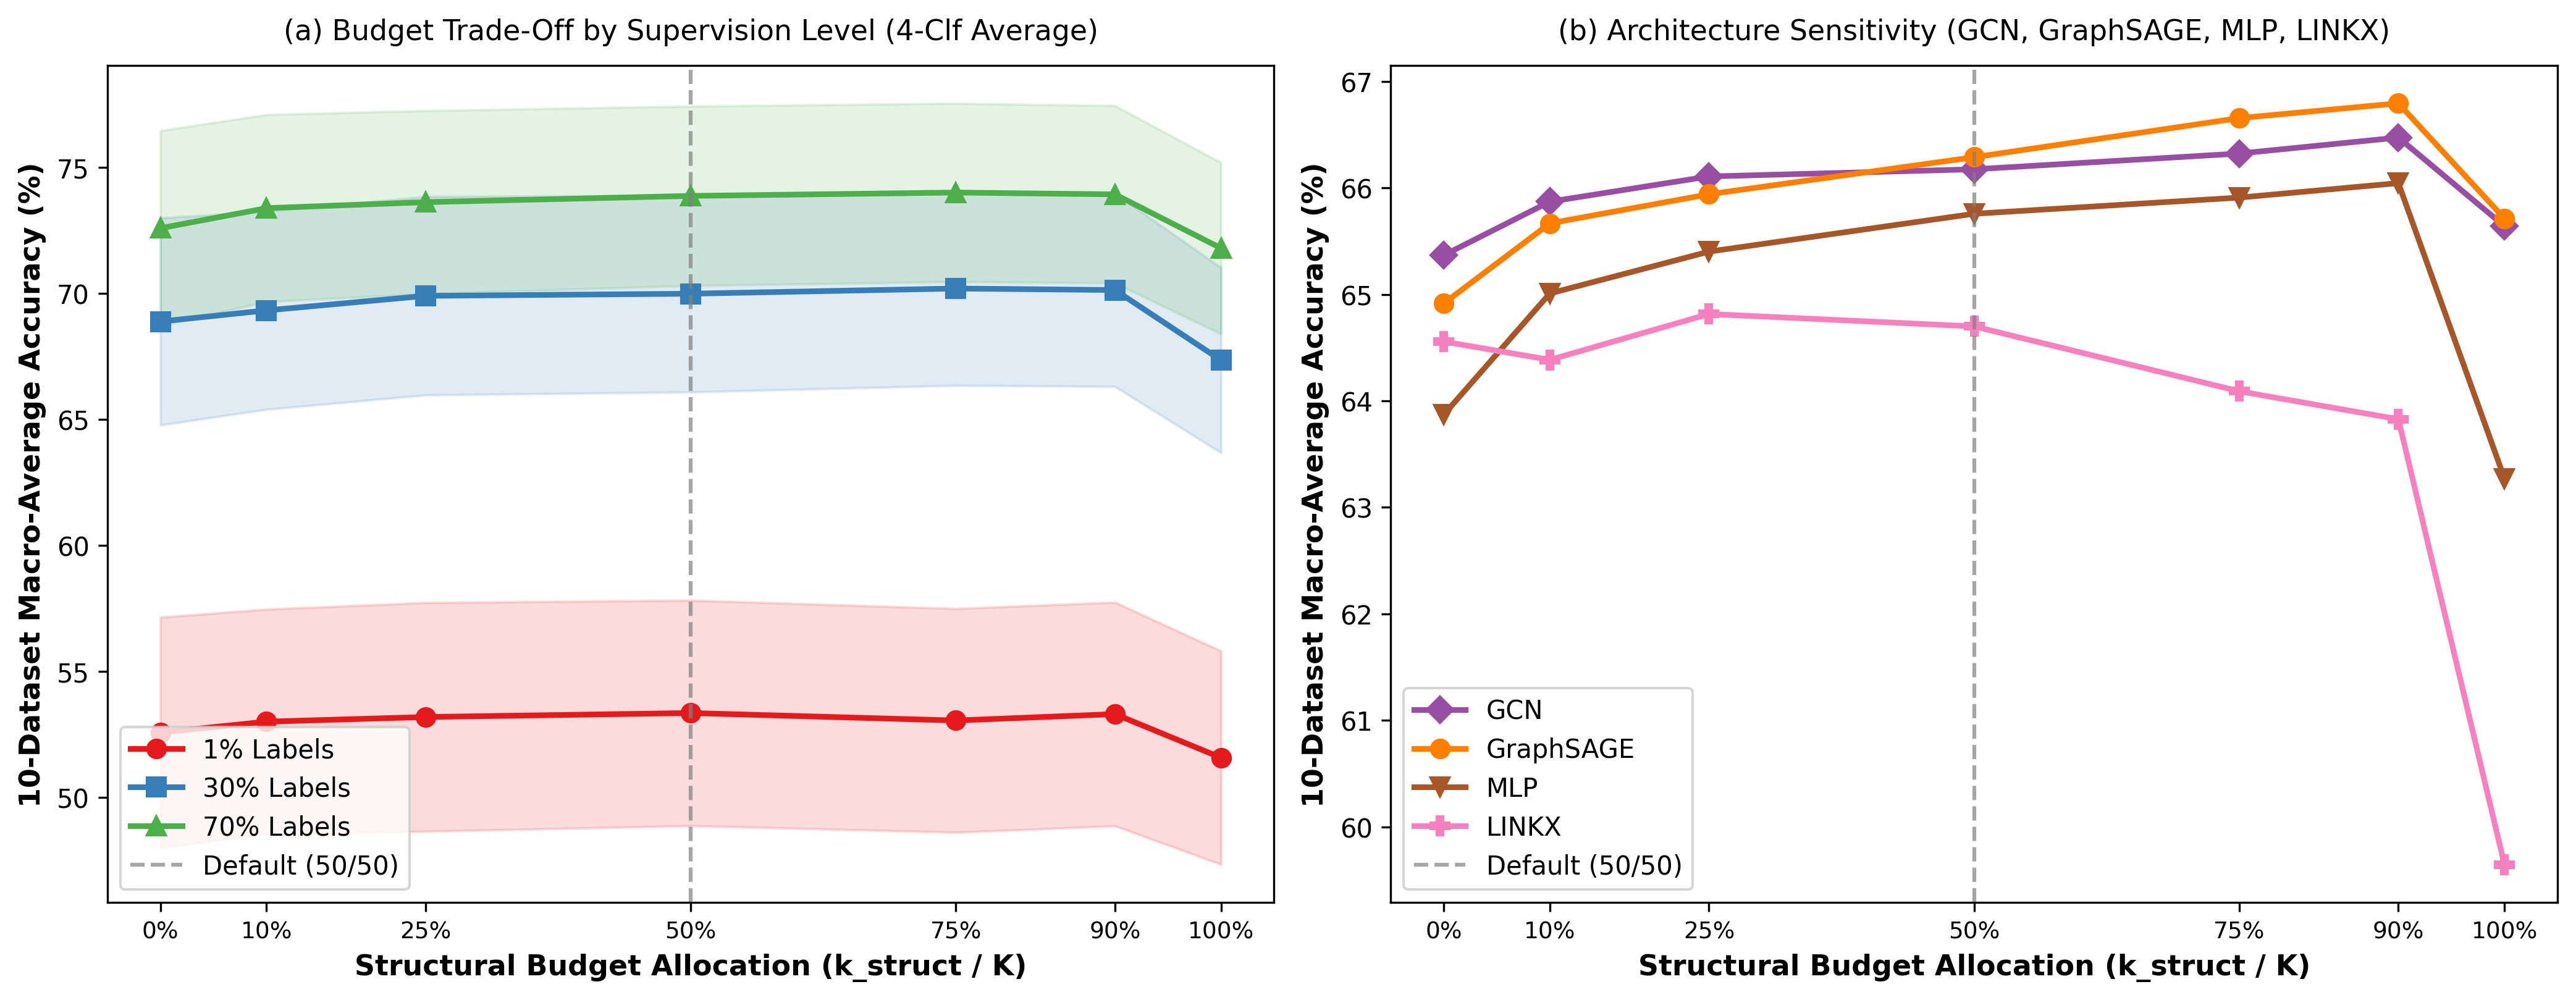

In [ ]:
# =============================================================================
# 2.4 EMBEDDING DIMENSION BUDGET SPLIT SWEEP (k_struct : k_label)
# =============================================================================
# Evaluates 7 budget splits across datasets, seeds, and classifiers.

import os, sys, time, copy, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------------------------------
# CONFIGURATION & HYPERPARAMETERS
# -----------------------------------------------------------------------------
budget_splits = [0.0, 0.10, 0.25, 0.50, 0.75, 0.90, 1.0]
split_names = [
    '0/100 (Pure Label)',
    '10/90 (Heavy Label)',
    '25/75 (Moderate Label)',
    '50/50 (Balanced Default)',
    '75/25 (Moderate Struct)',
    '90/10 (Heavy Struct)',
    '100/0 (Pure Struct)'
]
split_map = dict(zip(budget_splits, split_names))

split_datasets = [
    'cora', 'citeseer', 'pubmed', 'wikics', 'chameleon', 
    'squirrel', 'photo', 'computers', 'amazon-ratings', 'dblp'
]
split_seeds = [42, 123, 999]
split_ratios = [0.01, 0.30, 0.70]     # 1%, 30%, 70% label visibility regimes
CLASSIFIERS = ['GCN', 'GraphSAGE', 'MLP', 'LINKX']
PROBE_TYPE = '4_classifiers'

# Cache Management Controls:
# - CLEAR_CACHE: Set to True to wipe all saved budget split checkpoints
# - FORCE_RECOMPUTE: Set to True to ignore cache and re-evaluate models
CLEAR_CACHE = False
FORCE_RECOMPUTE = False

budget_ckpt_dir = os.path.join(BENCHMARK_DIR, 'budget_split_checkpoints')
os.makedirs(budget_ckpt_dir, exist_ok=True)

if CLEAR_CACHE and os.path.exists(budget_ckpt_dir):
    for f in glob.glob(os.path.join(budget_ckpt_dir, "budget_split_*.csv")):
        try:
            os.remove(f)
        except Exception:
            pass
    print(f"Cleared budget split checkpoints directory: {budget_ckpt_dir}")

budget_split_records = []

for ds_name in split_datasets:
    for r in split_ratios:
        r_pct = int(round(r * 100))
        ckpt_file = os.path.join(
            budget_ckpt_dir, 
            f"budget_split_{ds_name}_ratio_{r_pct:02d}pct_nonmask_4classifiers_seeds_{len(split_seeds)}.csv"
        )
        
        if not FORCE_RECOMPUTE and os.path.exists(ckpt_file):
            try:
                ds_df = pd.read_csv(ckpt_file)
                budget_split_records.extend(ds_df.to_dict('records'))
                print(f"  [CACHED] {ds_name.upper():14s} (ratio={r*100:4.1f}%, 4 classifiers) loaded ({len(ds_df)} records)")
                continue
            except Exception:
                pass

        print(f"\n>>> Processing Budget Split: {ds_name.upper()} (Ratio: {r*100:.1f}%, {len(split_seeds)} seeds, 4 classifiers)...")
        t0 = time.time()
        ds_records = []
        try:
            ds = bna.load_dataset(ds_name, root=os.path.join(BENCHMARK_DIR, 'data'))
            G, pyg, y = ds['G'], ds['pyg_data'], ds['labels']
            n = G.number_of_nodes()

            for s in split_seeds:
                base_non_mask = get_non_mask_data(ds_name, y, seed=s, base_mask_frac=0.7, masks_root=MASKS_ROOT)
                tr_mask, te_mask = split_non_mask_data(base_non_mask, y, seed=s, train_ratio=r)

                for b_ratio in budget_splits:
                    v_name = split_map[b_ratio]
                    cfg = ras.AblationConfig(
                        struct_mode="nystrom",
                        struct_ratio=b_ratio,
                        k_total=250,
                        enable_gt_channel=True,
                        enable_pseudo_channel=True,
                        pseudo_threshold=0.50,
                        hops=2,
                        alpha=0.5,
                        seed=s,
                        device=DEVICE
                    )
                    
                    emb, t_gen, diag = ras.generate_ablated_representation(G, pyg, y, tr_mask, cfg)
                    eval_res = ras.evaluate_representation_probe(
                        emb, y, tr_mask, te_mask,
                        probe_type=PROBE_TYPE,
                        edge_index=getattr(pyg, 'edge_index', None),
                        device=DEVICE
                    )

                    rec = {
                        'dataset': ds_name,
                        'ratio': r,
                        'seed': s,
                        'struct_ratio': b_ratio,
                        'split_name': v_name,
                        'k_struct': diag['k_struct'],
                        'k_label': diag['k_label'],
                        'accuracy': eval_res['accuracy'],      # 4-Classifier Average
                        'macro_f1': eval_res['macro_f1'],      # 4-Classifier Average
                        'micro_f1': eval_res['micro_f1'],      # 4-Classifier Average
                        'gen_time': t_gen
                    }
                    if 'per_classifier' in eval_res:
                        rec['acc_gcn'] = eval_res['per_classifier']['GCN']['accuracy']
                        rec['acc_gsage'] = eval_res['per_classifier']['GraphSAGE']['accuracy']
                        rec['acc_mlp'] = eval_res['per_classifier']['MLP']['accuracy']
                        rec['acc_linkx'] = eval_res['per_classifier']['LINKX']['accuracy']

                    ds_records.append(rec)
                    budget_split_records.append(rec)

            ds_df = pd.DataFrame(ds_records)
            ds_df.to_csv(ckpt_file, index=False)
            print(f"  [DONE]   {ds_name.upper():14s} (ratio={r*100:4.1f}%) in {time.time()-t0:5.1f}s")
        except Exception as e:
            print(f"  [ERROR]  {ds_name} (ratio={r*100:.1f}%): {e}")

df_budget = pd.DataFrame(budget_split_records)

# -----------------------------------------------------------------------------
# 1. GRAND SUMMARY MASTER TABLE ACROSS ALL 10 DATASETS & 3 SUPERVISION RATIOS
# -----------------------------------------------------------------------------
print("\n" + "=" * 90)
print(f"  BUDGET SPLIT GRAND SYNTHESIS (10 DATASETS, 3 SEEDS, 3 RATIOS, 4-CLASSIFIER AVERAGE)")
print("=" * 90)

summary_rows = []
for b_ratio in budget_splits:
    v_name = split_map[b_ratio]
    v_sub = df_budget[df_budget['struct_ratio'] == b_ratio]
    if v_sub.empty:
        continue
    
    row = {
        'Split (Struct/Label)': v_name,
        'k_struct': int(v_sub['k_struct'].iloc[0]),
        'k_label': int(v_sub['k_label'].iloc[0]),
        'Average (4 Clf) (%)': f"{v_sub['accuracy'].mean():.2f} ± {v_sub['accuracy'].std():.2f}",
        'Macro F1 (%)': f"{v_sub['macro_f1'].mean():.2f} ± {v_sub['macro_f1'].std():.2f}",
        'Gen Time (s)': f"{v_sub['gen_time'].mean():.3f}s"
    }
    if 'acc_gcn' in v_sub.columns:
        row['GCN (%)'] = f"{v_sub['acc_gcn'].mean():.2f}"
        row['GraphSAGE (%)'] = f"{v_sub['acc_gsage'].mean():.2f}"
        row['MLP (%)'] = f"{v_sub['acc_mlp'].mean():.2f}"
        row['LINKX (%)'] = f"{v_sub['acc_linkx'].mean():.2f}"
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

# -----------------------------------------------------------------------------
# 2. PER-SUPERVISION RATIO BREAKDOWN (1%, 30%, 70%)
# -----------------------------------------------------------------------------
for r in split_ratios:
    r_sub = df_budget[df_budget['ratio'] == r]
    if not r_sub.empty:
        print("\n" + "-" * 80)
        print(f"  BUDGET ALLOCATION PERFORMANCE UNDER {int(round(r*100))}% TRAINING SUPERVISION")
        print("-" * 80)
        r_rows = []
        for b_ratio in budget_splits:
            b_sub = r_sub[r_sub['struct_ratio'] == b_ratio]
            if b_sub.empty:
                continue
            r_rows.append({
                'Split (Struct/Label)': split_map[b_ratio],
                'Average (4 Clf) (%)': f"{b_sub['accuracy'].mean():.2f} ± {b_sub['accuracy'].std():.2f}",
                'GCN (%)': f"{b_sub['acc_gcn'].mean():.2f}" if 'acc_gcn' in b_sub.columns else "---",
                'GraphSAGE (%)': f"{b_sub['acc_gsage'].mean():.2f}" if 'acc_gsage' in b_sub.columns else "---",
                'MLP (%)': f"{b_sub['acc_mlp'].mean():.2f}" if 'acc_mlp' in b_sub.columns else "---",
                'LINKX (%)': f"{b_sub['acc_linkx'].mean():.2f}" if 'acc_linkx' in b_sub.columns else "---",
                'Macro F1 (%)': f"{b_sub['macro_f1'].mean():.2f} ± {b_sub['macro_f1'].std():.2f}"
            })
        display(pd.DataFrame(r_rows))

# -----------------------------------------------------------------------------
# 3. HIGH-RESOLUTION PUBLICATION VISUALIZATIONS
# -----------------------------------------------------------------------------
plt.figure(figsize=(14, 5.5), dpi=300)

# Panel 1: Budget Allocation across Supervision Regimes (1%, 30%, 70%)
plt.subplot(1, 2, 1)
ratio_colors = {0.01: '#e41a1c', 0.30: '#377eb8', 0.70: '#4daf4a'}
ratio_markers = {0.01: 'o', 0.30: 's', 0.70: '^'}

for r in split_ratios:
    r_sub = df_budget[df_budget['ratio'] == r]
    if r_sub.empty:
        continue
    means = [r_sub[r_sub['struct_ratio'] == b]['accuracy'].mean() for b in budget_splits]
    stds = [r_sub[r_sub['struct_ratio'] == b]['accuracy'].std() for b in budget_splits]
    pct_lbl = f"{int(round(r*100))}% Labels"
    plt.plot(budget_splits, means, marker=ratio_markers[r], color=ratio_colors[r], 
             linewidth=2.2, markersize=7, label=pct_lbl)
    plt.fill_between(budget_splits, np.array(means) - 0.2*np.array(stds), np.array(means) + 0.2*np.array(stds), 
                     color=ratio_colors[r], alpha=0.15)

plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='Default (50/50)')
plt.xticks(budget_splits, [f"{int(b*100)}%" for b in budget_splits], fontsize=9)
plt.xlabel("Structural Budget Allocation (k_struct / K)", fontsize=11, fontweight='bold')
plt.ylabel("10-Dataset Macro-Average Accuracy (%)", fontsize=11, fontweight='bold')
plt.title("(a) Budget Trade-Off by Supervision Level (4-Clf Average)", fontsize=11, pad=10)
plt.grid(False)
plt.legend(loc='lower left', fontsize=10)

# Panel 2: Budget Allocation across 4 Canonical Classifier Architectures
plt.subplot(1, 2, 2)
clf_colors = {'GCN': '#984ea3', 'GraphSAGE': '#ff7f00', 'MLP': '#a65628', 'LINKX': '#f781bf'}
clf_markers = {'GCN': 'D', 'GraphSAGE': 'o', 'MLP': 'v', 'LINKX': 'P'}

for clf in CLASSIFIERS:
    col = f"acc_{clf.lower()}" if f"acc_{clf.lower()}" in df_budget.columns else ('acc_gsage' if clf == 'GraphSAGE' else None)
    if col and col in df_budget.columns:
        means = [df_budget[df_budget['struct_ratio'] == b][col].mean() for b in budget_splits]
        plt.plot(budget_splits, means, marker=clf_markers[clf], color=clf_colors[clf],
                 linewidth=2.2, markersize=7, label=clf)

plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='Default (50/50)')
plt.xticks(budget_splits, [f"{int(b*100)}%" for b in budget_splits], fontsize=9)
plt.xlabel("Structural Budget Allocation (k_struct / K)", fontsize=11, fontweight='bold')
plt.ylabel("10-Dataset Macro-Average Accuracy (%)", fontsize=11, fontweight='bold')
plt.title("(b) Architecture Sensitivity (GCN, GraphSAGE, MLP, LINKX)", fontsize=11, pad=10)
plt.grid(False)
plt.legend(loc='lower left', fontsize=10)

plt.tight_layout()
fig_save_path = os.path.join(BENCHMARK_DIR, 'ablation_budget_split_tradeoff.png')
plt.savefig(fig_save_path, bbox_inches='tight')
print(f"\nSaved budget split diagnostic plot to: {fig_save_path}")
plt.show()



### 2.5 Hops Ablation Across Multiple Label Ratios
Evaluates the diffusion radius (hops) while varying the label mask ratio (0%, 1%, 10%, 30%, 70%) for embedding generation. Probing is fixed to the standard 70% train split to purely evaluate representation quality.



Running Diffusion Radius (hops) vs Train Ratio Sweep across 10 datasets...

>>> EVALUATING TRAIN RATIO = 0.0%
  Evaluating CORA...
  [DONE]   CORA            in  73.8s | Mean Peak: 76.95%
  Evaluating CITESEER...
  [DONE]   CITESEER        in  73.5s | Mean Peak: 58.13%
  Evaluating PUBMED...
  [DONE]   PUBMED          in 105.2s | Mean Peak: 80.90%
  Evaluating WIKICS...
  [DONE]   WIKICS          in 194.6s | Mean Peak: 77.08%
  Evaluating CHAMELEON...
  [DONE]   CHAMELEON       in  88.6s | Mean Peak: 64.45%
  Evaluating SQUIRREL...
  [DONE]   SQUIRREL        in 158.0s | Mean Peak: 48.07%
  Evaluating PHOTO...
  [DONE]   PHOTO           in 129.5s | Mean Peak: 90.67%
  Evaluating COMPUTERS...
  [DONE]   COMPUTERS       in 217.9s | Mean Peak: 86.38%
  Evaluating AMAZON-RATINGS...
  [DONE]   AMAZON-RATINGS  in 145.5s | Mean Peak: 43.81%
  Evaluating DBLP...
  [DONE]   DBLP            in  97.0s | Mean Peak: 93.66%

>>> EVALUATING TRAIN RATIO = 1.0%
  Evaluating CORA...
  [DONE]   CORA     

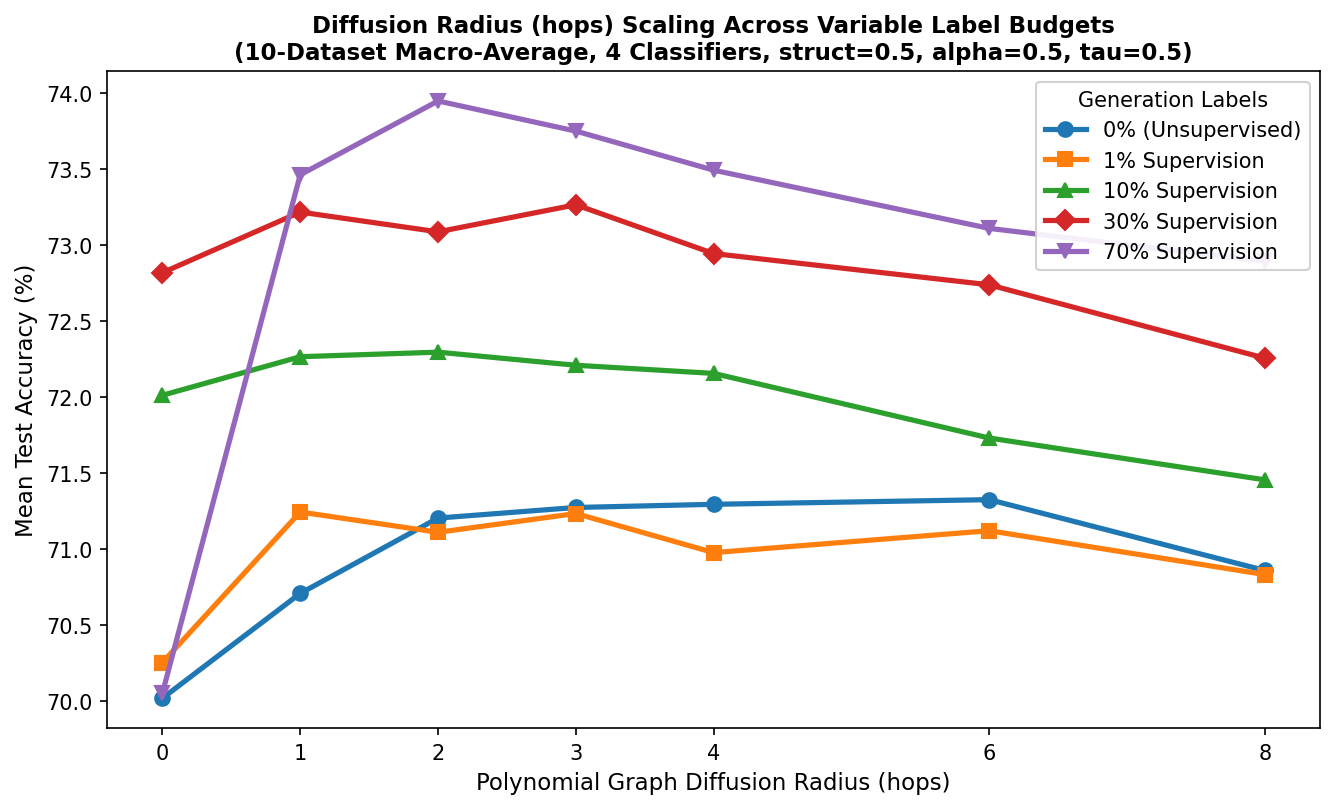

,hop=0,hop=1,hop=2,hop=3,hop=4,hop=6,hop=8
0%,70.02,70.71,71.20,71.27,71.29,71.32,70.86
1%,70.25,71.24,71.11,71.23,70.98,71.12,70.83
10%,72.01,72.27,72.30,72.21,72.16,71.73,71.46
30%,72.82,73.22,73.09,73.27,72.94,72.74,72.26
70%,70.05,73.46,73.95,73.75,73.49,73.11,72.89


In [ ]:
import os, time, sys, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import rigorous_ablation_system as ras
from benchmark_new_algebraic import BENCHMARK_DIR, DEVICE
MASKS_ROOT = globals().get('MASKS_ROOT', r'./masks')
# Reuse the split functions defined earlier in the notebook
# (Assuming get_non_mask_data and split_non_mask_data are defined in previous cells)

seeds_list = [42, 123, 77]
hops_list = [0, 1, 2, 3, 4, 6, 8]
train_ratios = [0.0, 0.01, 0.10, 0.30, 0.70]
CLASSIFIERS = ['GCN', 'GraphSAGE', 'MLP', 'LINKX']
PROBE_TYPE = '4_classifiers'
FORCE_RECOMPUTE = False

hops_eval_datasets = [
    'cora', 'citeseer', 'pubmed', 'wikics', 'chameleon', 
    'squirrel', 'photo', 'computers', 'amazon-ratings', 'dblp'
]

hops_ratio_ckpt_dir = os.path.join(BENCHMARK_DIR, 'hops_ratio_checkpoints')
os.makedirs(hops_ratio_ckpt_dir, exist_ok=True)
seed_tag = f"seeds_{'_'.join(map(str, sorted(seeds_list)))}"

print(f"\nRunning Diffusion Radius (hops) vs Train Ratio Sweep across {len(hops_eval_datasets)} datasets...")

macro_ratio_grids = {}

for tr in train_ratios:
    print(f"\n{'='*60}\n>>> EVALUATING TRAIN RATIO = {tr*100:.1f}%\n{'='*60}")
    ds_means = []
    
    for ds_name in hops_eval_datasets:
        ckpt_file = os.path.join(hops_ratio_ckpt_dir, f"hops_ratio_{tr}_{ds_name}_{seed_tag}_4classifiers.npy")
        
        if not FORCE_RECOMPUTE and os.path.exists(ckpt_file):
            mat = np.load(ckpt_file)
            ds_means.append(mat.mean(axis=0))
            print(f"  [CACHED] {ds_name.upper():15s} | Mean Peak: {mat.mean(axis=0).max():.2f}%")
            continue
            
        print(f"  Evaluating {ds_name.upper()}...")
        t0 = time.time()
        try:
            ds = bna.load_dataset(ds_name, root=os.path.join(BENCHMARK_DIR, 'data'))
            G, pyg, y = ds['G'], ds['pyg_data'], ds['labels']
            
            mat = np.zeros((len(seeds_list), len(hops_list)))
            for s_idx, s in enumerate(seeds_list):
                np.random.seed(s)
                base_non_mask = get_non_mask_data(ds_name, y, seed=s, base_mask_frac=0.7, masks_root=MASKS_ROOT)
                
                # Standard downstream split (70%) for PROBE TRAINING
                probe_tr_mask, probe_te_mask = split_non_mask_data(base_non_mask, y, seed=s, train_ratio=0.70)
                
                # Embedding generation split (variable)
                gen_tr_mask, _ = split_non_mask_data(base_non_mask, y, seed=s, train_ratio=tr)
                
                for h_idx, h in enumerate(hops_list):
                    cfg = ras.AblationConfig(hops=h, device=DEVICE, seed=s, alpha=0.5, pseudo_threshold=0.5)
                    emb, _, _ = ras.generate_ablated_representation(G, pyg, y, gen_tr_mask, cfg)
                    res = ras.evaluate_representation_probe(
                        emb, y, probe_tr_mask, probe_te_mask,
                        probe_type=PROBE_TYPE,
                        edge_index=getattr(pyg, 'edge_index', None),
                        device=DEVICE
                    )
                    mat[s_idx, h_idx] = res['accuracy']
                    
            np.save(ckpt_file, mat)
            ds_means.append(mat.mean(axis=0))
            print(f"  [DONE]   {ds_name.upper():15s} in {time.time()-t0:5.1f}s | Mean Peak: {mat.mean(axis=0).max():.2f}%")
        except Exception as e:
            print(f"  [ERROR]  {ds_name}: {e}")
            
    if ds_means:
        macro_ratio_grids[tr] = np.mean(ds_means, axis=0)

print("\nPlotting Multi-Ratio Hops Scaling Curve...")
plt.figure(figsize=(9, 5.5), dpi=150)
markers = ['o', 's', '^', 'D', 'v']

for idx, tr in enumerate(train_ratios):
    if tr not in macro_ratio_grids: continue
    ys = macro_ratio_grids[tr]
    lbl = f"{int(tr*100)}% Supervision" if tr > 0 else "0% (Unsupervised)"
    plt.plot(hops_list, ys, marker=markers[idx % len(markers)], linewidth=2.5, markersize=7, label=lbl)

# Add Global Average across all Label Budgets
if macro_ratio_grids:
    avg_ys = np.mean(list(macro_ratio_grids.values()), axis=0)
    plt.plot(hops_list, avg_ys, marker='*', color='black', linewidth=3.5, linestyle='--', markersize=12, label='Average (All Ratios)')

plt.title("Diffusion Radius (hops) Scaling Across Variable Label Budgets\n(10-Dataset Macro-Average, 4 Classifiers, struct=0.5, alpha=0.5, tau=0.5)", fontsize=11, fontweight='bold')
plt.xlabel("Polynomial Graph Diffusion Radius (hops)", fontsize=11)
plt.ylabel("Mean Test Accuracy (%)", fontsize=11)
plt.xticks(hops_list)
plt.grid(False)
plt.legend(title="Generation Labels", framealpha=0.9)
plt.tight_layout()

curve_path = os.path.join(BENCHMARK_DIR, 'ablation_hops_vs_ratios_curve.png')
plt.savefig(curve_path, bbox_inches='tight')
print(f"Saved plot to {curve_path}")
plt.show()

# Print Table
df_res = pd.DataFrame(index=[f"{int(tr*100)}%" for tr in train_ratios], columns=[f"hop={h}" for h in hops_list])
for tr in train_ratios:
    if tr in macro_ratio_grids:
        for h_idx, h in enumerate(hops_list):
            df_res.loc[f"{int(tr*100)}%", f"hop={h}"] = float(f"{macro_ratio_grids[tr][h_idx]:.2f}")

# Add Average Row to DataFrame
if not df_res.empty:
    df_res.loc["Average"] = df_res.mean(axis=0)

display(df_res.round(2))


In [ ]:
df_res = pd.DataFrame(index=[f"{int(tr*100)}%" for tr in train_ratios], columns=[f"hop={h}" for h in hops_list])
for tr in train_ratios:
    if tr in macro_ratio_grids:
        for h_idx, h in enumerate(hops_list):
            df_res.loc[f"{int(tr*100)}%", f"hop={h}"] = float(f"{macro_ratio_grids[tr][h_idx]:.2f}")

# Add Average Row to DataFrame
if not df_res.empty:
    df_res.loc["Average"] = df_res.mean(axis=0)

display(df_res.round(2))


,hop=0,hop=1,hop=2,hop=3,hop=4,hop=6,hop=8
0%,70.02,70.71,71.2,71.27,71.29,71.32,70.86
1%,70.25,71.24,71.11,71.23,70.98,71.12,70.83
10%,72.01,72.27,72.3,72.21,72.16,71.73,71.46
30%,72.82,73.22,73.09,73.27,72.94,72.74,72.26
70%,70.05,73.46,73.95,73.75,73.49,73.11,72.89
Average,71.03,72.18,72.33,72.346,72.172,72.004,71.66
